# Patient 1 

In this jupyter notebook the data of patient 1 is loaded, inspected and processed. 

In [1]:
# imports
import pickle
#import os
#import re 
import mne
import numpy as np
import matplotlib.pyplot as plt
#from pathlib import Path
#from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
#import sklearn.metrics as metrics
#import scipy as sp
#import scipy.stats as stats
import warnings
#from sklearn.pipeline import make_pipeline
#from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
#import logging
#import math

# utils functions
from utils.preprocessing import all_have_same_condition, inspect_session, get_n_epochs, get_iteration_structure, get_n_iterations, load_session_chached, merge_sessions, _have_same_preprocessing
from utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv
from utils.online_simulation import online_simulation, online_adaptation_simulation_sw

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')



In [ ]:
import line_profiler
%load_ext line_profiler

# Example:
# %lprun -f my_function my_function(500000)

## Real online simulation

Procedure
1. Load data
2. Train a classifier on calibration data and evaluate the offline performance
3. Test static classifier in an online simulation of session 3
4. Test adaptive sliding window 

### Results

### loop s4-17

Loading file:  data_p3_P3_S3_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S3_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S3_anonymized.pkl
Loading file:  data_p3_P3_S4_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S4_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S4_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 15.33333333 14.33333333 15.33333333  8.16666667]
Run 2: [ 8.33333333 15.33333333 15.33333333  9.33333333 14.33333333 15.16666667]
Run 3: [12.33333333 11.33333333 15.33333333 15.33333333 15.33333333  9.16666667]
Run 4: [11.33333333 12.33333333 15.33333333  8.33333333 15.33333333 14.16666667]
Run 5: [15.33333333  8.33333333 12.33333333 15.33333333 15.33333333 15.16666667]
Run 6: [13.33333333 15.33333333 15.33333333 15.33333333 15.33333333 15.16666667]
Run 7: [15.3333

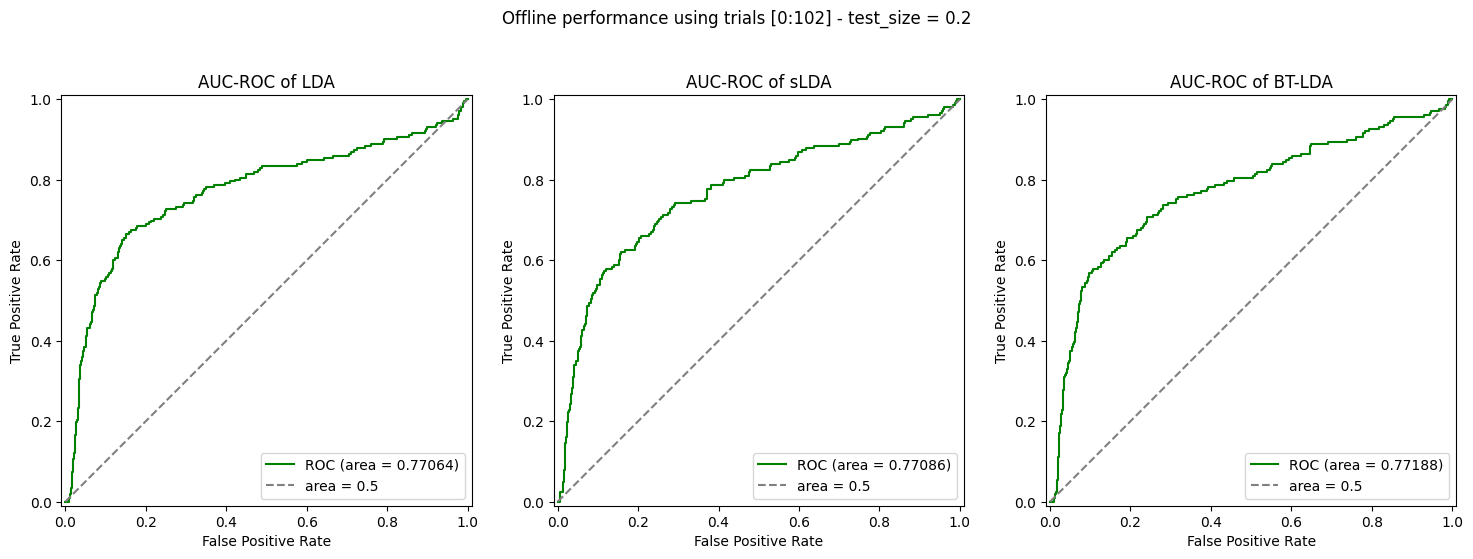

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.8105891080864207
Mean AUC score of sLDA: 	 0.7976040515374949
Mean AUC score of BT-LDA: 	 0.797448863722388
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 

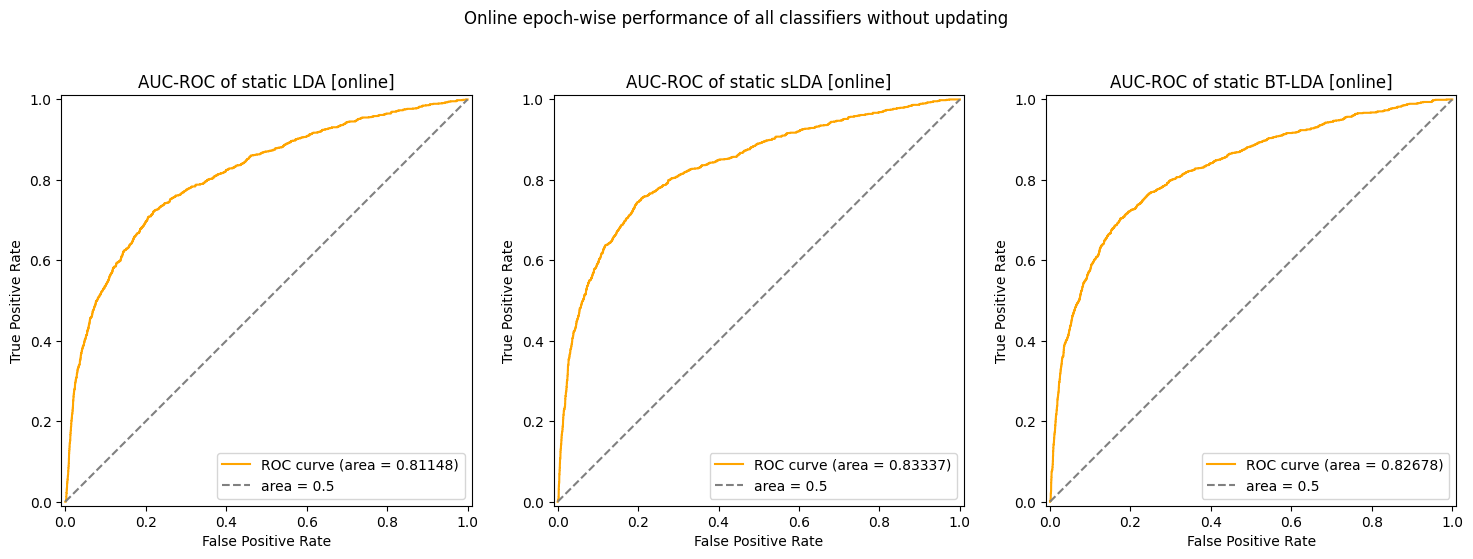

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.92857
Accuracy SLDA: 0.91667
Accuracy BT-LDA: 0.91667
trial 0/84
trial 1/84
trial 2/84
trial 3/84
trial 4/84
trial 5/84
trial 6/84
trial 7/84
trial 8/84
trial 9/84
trial 10/84
trial 11/84
trial 12/84
trial 13/84
trial 14/84
trial 15/84
trial 16/84
trial 17/84
trial 18/84
trial 19/84
trial 20/84
trial 21/84
trial 22/84
trial 23/84
trial 24/84
trial 25/84
trial 26/84
trial 27/84
trial 28/84
trial 29/84
trial 30/84
trial 31/84
trial 32/84
trial 33/84
trial 34/84
trial 35/84
trial 36/84
trial 37/84
trial 38/84
trial 39/84
trial 40/84
trial 41/84
trial 42/84
trial 43/84
trial 44/84
trial 45/84
trial 46/84
trial 47/84
trial 48/84
trial 49/84
trial 50/84
trial 51/84
trial 52/84
trial 53/84
trial 54/84
trial 55/84
trial 56/84
trial 57/84
trial 58/84
trial 59/84
trial 60/84
trial 61/84
trial 62/84
trial 63/84
trial 64/84
trial 65/84
trial 66/84
trial 67/84
trial 68/84
trial 69/84
trial 70/84
trial 71/8

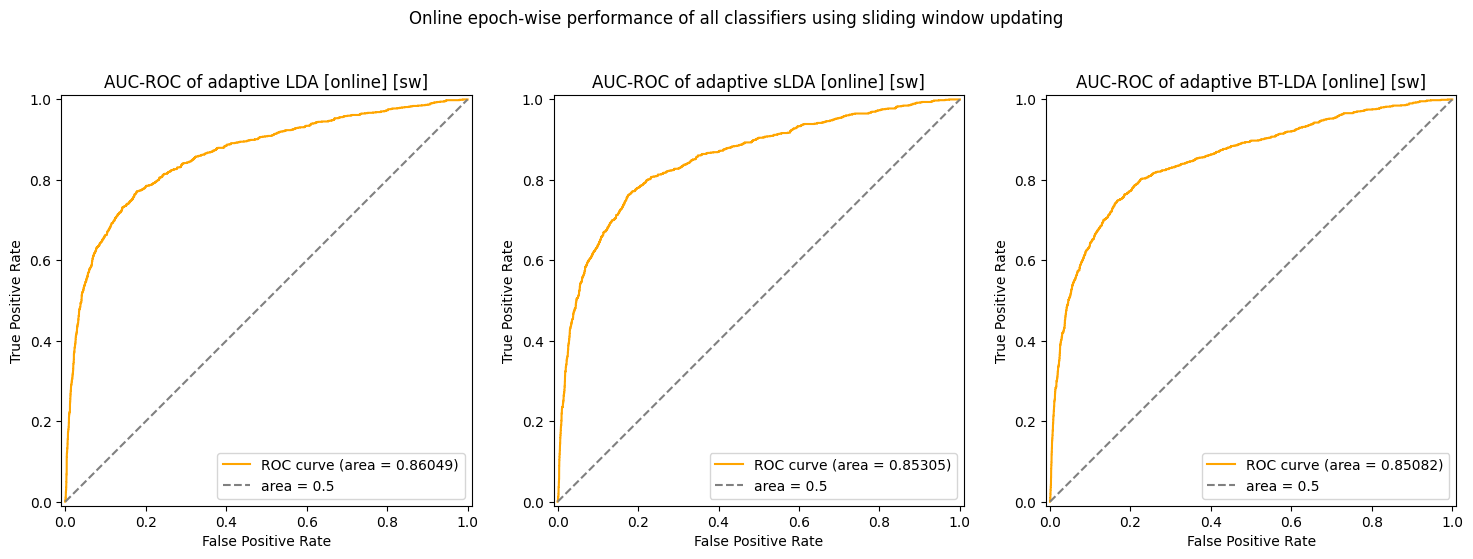

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.94048
Accuracy SLDA: 0.92857
Accuracy BT-LDA: 0.92857
Loading file:  data_p3_P3_S4_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S4_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S4_anonymized.pkl
Loading file:  data_p3_P3_S5_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S5_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S5_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 14.33333333 11.33333333  9.33333333 15.33333333 15.16666667]
Run 2: [15.33333333 15.33333333 15.33333333 10.33333333 15.33333333 15.16666667]
Run 3: [15.33333333 15.33333333 13.33333333 15.33333333  9.33333333 15.16666667]
Run 4: [15.33333333 12.33333333 15.33333333 14.33333333  9.33333333 15.16666667]
Run 5: [15.33333333  8.333333

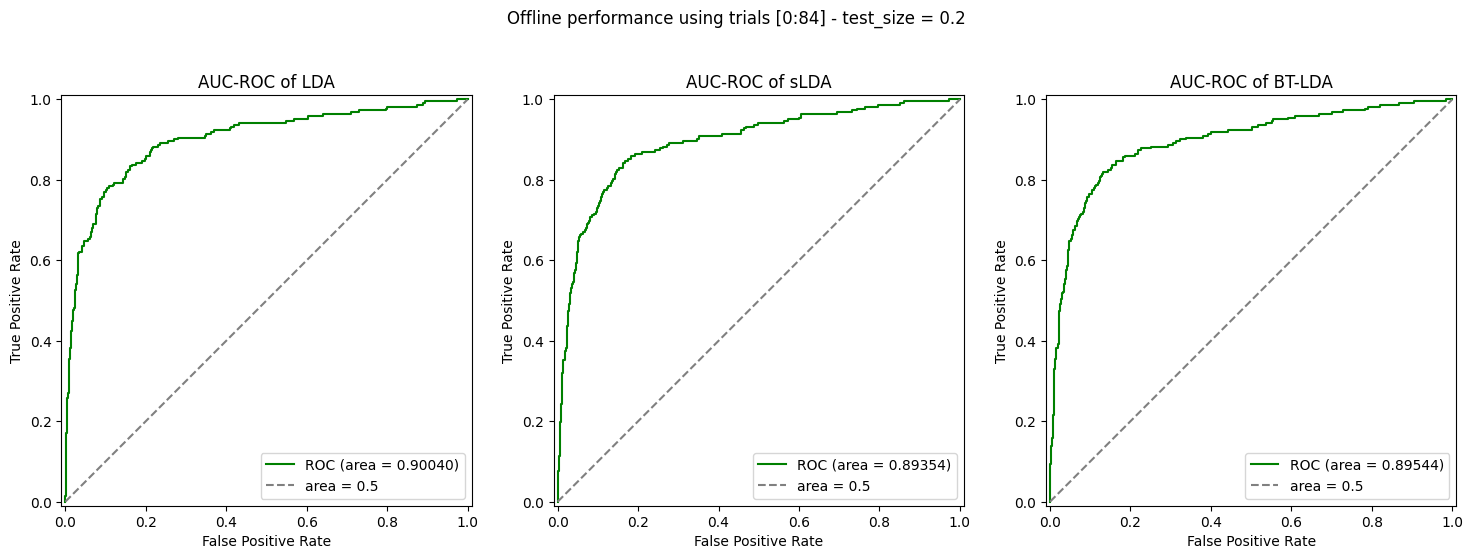

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.8714320963172548
Mean AUC score of sLDA: 	 0.8657310369042048
Mean AUC score of BT-LDA: 	 0.8688875264715784
trial 0/54
trial 1/54
trial 2/54
trial 3/54
trial 4/54
trial 5/54
trial 6/54
trial 7/54
trial 8/54
trial 9/54
trial 10/54
trial 11/54
trial 12/54
trial 13/54
trial 14/54
trial 15/54
trial 16/54
trial 17/54
trial 18/54
trial 19/54
trial 20/54
trial 21/54
trial 22/54
trial 23/54
trial 24/54
trial 25/54
trial 26/54
trial 27/54
trial 28/54
trial 29/54
trial 30/54
trial 31/54
trial 32/54
trial 33/54
trial 34/54
trial 35/54
trial 36/54
trial 37/54
trial 38/54
trial 39/54
trial 40/54
trial 41/54
trial 42/54
trial 43/54
trial 44/54
trial 45/54
trial 46/54
trial 47/54
trial 48/54
trial 49/54
trial 50/54
trial 51/54
trial 52/54
trial 53/54
------------------ Epoch-wise performance ------------------


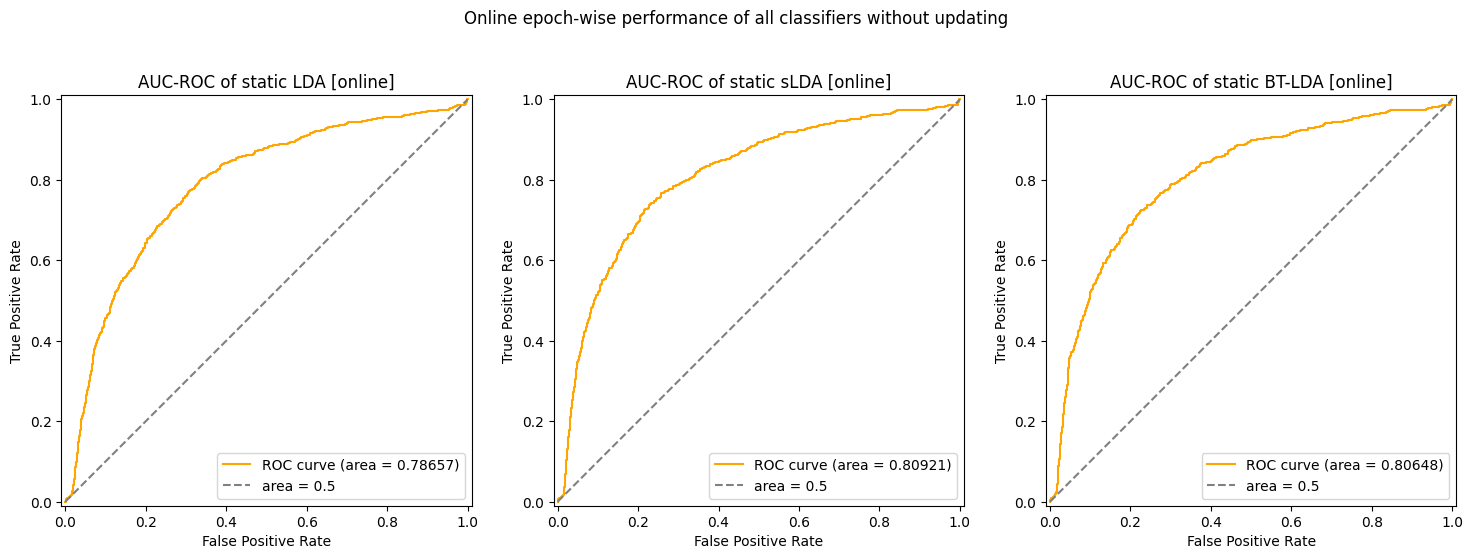

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.85185
Accuracy SLDA: 0.88889
Accuracy BT-LDA: 0.87037
trial 0/54
trial 1/54
trial 2/54
trial 3/54
trial 4/54
trial 5/54
trial 6/54
trial 7/54
trial 8/54
trial 9/54
trial 10/54
trial 11/54
trial 12/54
trial 13/54
trial 14/54
trial 15/54
trial 16/54
trial 17/54
trial 18/54
trial 19/54
trial 20/54
trial 21/54
trial 22/54
trial 23/54
trial 24/54
trial 25/54
trial 26/54
trial 27/54
trial 28/54
trial 29/54
trial 30/54
trial 31/54
trial 32/54
trial 33/54
trial 34/54
trial 35/54
trial 36/54
trial 37/54
trial 38/54
trial 39/54
trial 40/54
trial 41/54
trial 42/54
trial 43/54
trial 44/54
trial 45/54
trial 46/54
trial 47/54
trial 48/54
trial 49/54
trial 50/54
trial 51/54
trial 52/54
trial 53/54
------------------ Epoch-wise performance ------------------


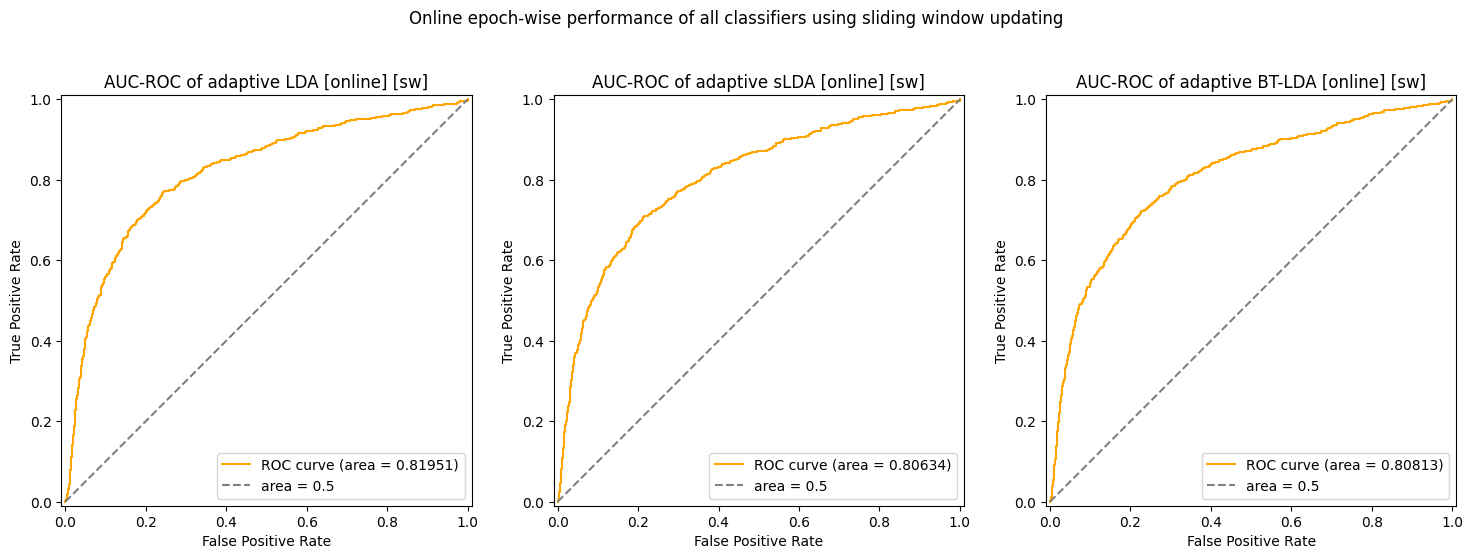

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.87037
Accuracy SLDA: 0.85185
Accuracy BT-LDA: 0.85185
Loading file:  data_p3_P3_S5_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S5_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S5_anonymized.pkl
Loading file:  data_p3_P3_S6_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S6_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S6_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 15.33333333 10.33333333  8.33333333  8.16666667]
Run 2: [ 9.33333333 15.33333333  9.33333333 11.33333333 15.33333333 15.16666667]
Run 3: [11.33333333 11.33333333 12.33333333 15.33333333 15.33333333 15.16666667]
Run 4: [ 9.33333333  9.33333333 10.33333333 10.33333333 15.33333333 14.16666667]
Run 5: [12.33333333 11.333333

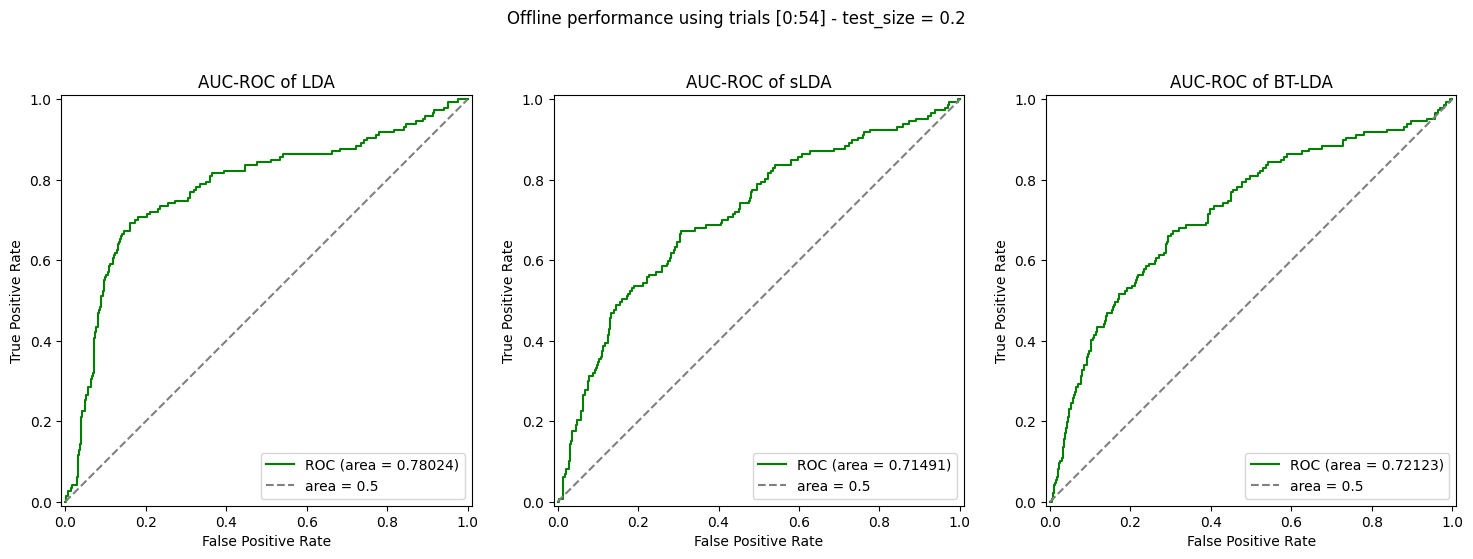

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.8132443289224953
Mean AUC score of sLDA: 	 0.7641895085066163
Mean AUC score of BT-LDA: 	 0.767828449905482
trial 0/72
trial 1/72
trial 2/72
trial 3/72
trial 4/72
trial 5/72
trial 6/72
trial 7/72
trial 8/72
trial 9/72
trial 10/72
trial 11/72
trial 12/72
trial 13/72
trial 14/72
trial 15/72
trial 16/72
trial 17/72
trial 18/72
trial 19/72
trial 20/72
trial 21/72
trial 22/72
trial 23/72
trial 24/72
trial 25/72
trial 26/72
trial 27/72
trial 28/72
trial 29/72
trial 30/72
trial 31/72
trial 32/72
trial 33/72
trial 34/72
trial 35/72
trial 36/72
trial 37/72
trial 38/72
trial 39/72
trial 40/72
trial 41/72
trial 42/72
trial 43/72
trial 44/72
trial 45/72
trial 46/72
trial 47/72
trial 48/72
trial 49/72
trial 50/72
trial 51/72
trial 52/72
trial 53/72
trial 54/72
trial 55/72
trial 56/72
trial 57/72
trial 58/72
trial 59/72
trial 60/72
trial 61/72
trial 62/72
trial 63/72
trial 64/72
trial 65/72
trial 66/72
trial 67/72
trial 

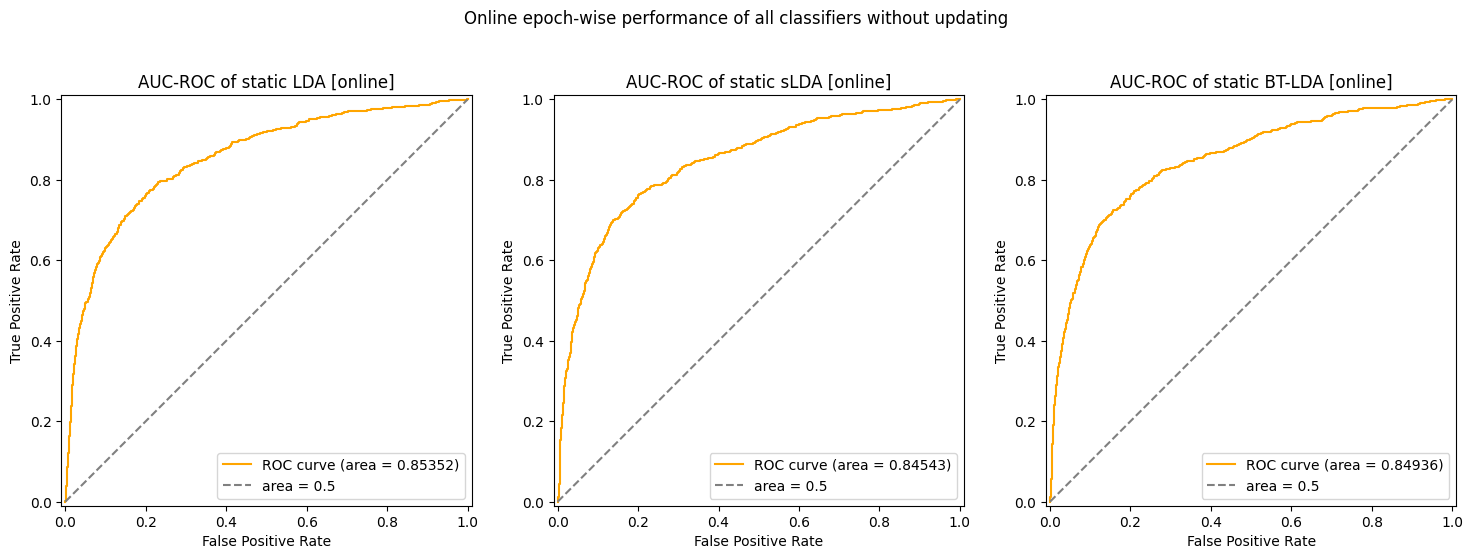

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.97222
Accuracy SLDA: 0.94444
Accuracy BT-LDA: 0.95833
trial 0/72
trial 1/72
trial 2/72
trial 3/72
trial 4/72
trial 5/72
trial 6/72
trial 7/72
trial 8/72
trial 9/72
trial 10/72
trial 11/72
trial 12/72
trial 13/72
trial 14/72
trial 15/72
trial 16/72
trial 17/72
trial 18/72
trial 19/72
trial 20/72
trial 21/72
trial 22/72
trial 23/72
trial 24/72
trial 25/72
trial 26/72
trial 27/72
trial 28/72
trial 29/72
trial 30/72
trial 31/72
trial 32/72
trial 33/72
trial 34/72
trial 35/72
trial 36/72
trial 37/72
trial 38/72
trial 39/72
trial 40/72
trial 41/72
trial 42/72
trial 43/72
trial 44/72
trial 45/72
trial 46/72
trial 47/72
trial 48/72
trial 49/72
trial 50/72
trial 51/72
trial 52/72
trial 53/72
trial 54/72
trial 55/72
trial 56/72
trial 57/72
trial 58/72
trial 59/72
trial 60/72
trial 61/72
trial 62/72
trial 63/72
trial 64/72
trial 65/72
trial 66/72
trial 67/72
trial 68/72
trial 69/72
trial 70/72
trial 71/7

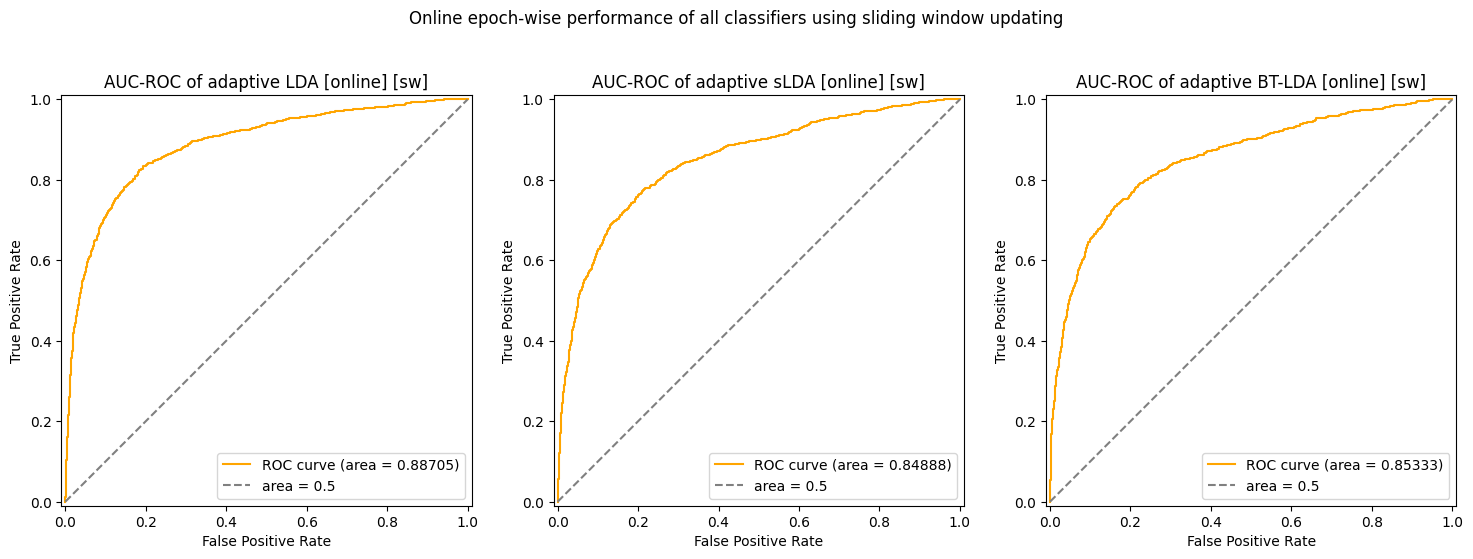

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.97222
Accuracy SLDA: 0.94444
Accuracy BT-LDA: 0.95833
Loading file:  data_p3_P3_S6_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S6_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S6_anonymized.pkl
Loading file:  data_p3_P3_S7_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S7_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S7_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 10.33333333 15.33333333 15.33333333 15.16666667]
Run 2: [12.33333333 15.33333333 10.33333333 15.33333333 15.33333333 12.16666667]
Run 3: [14.33333333 10.33333333 15.33333333 15.33333333 15.33333333 15.16666667]
Run 4: [ 8.33333333 15.33333333  9.33333333 15.33333333 10.33333333 15.16666667]
Run 5: [11.33333333  8.333333

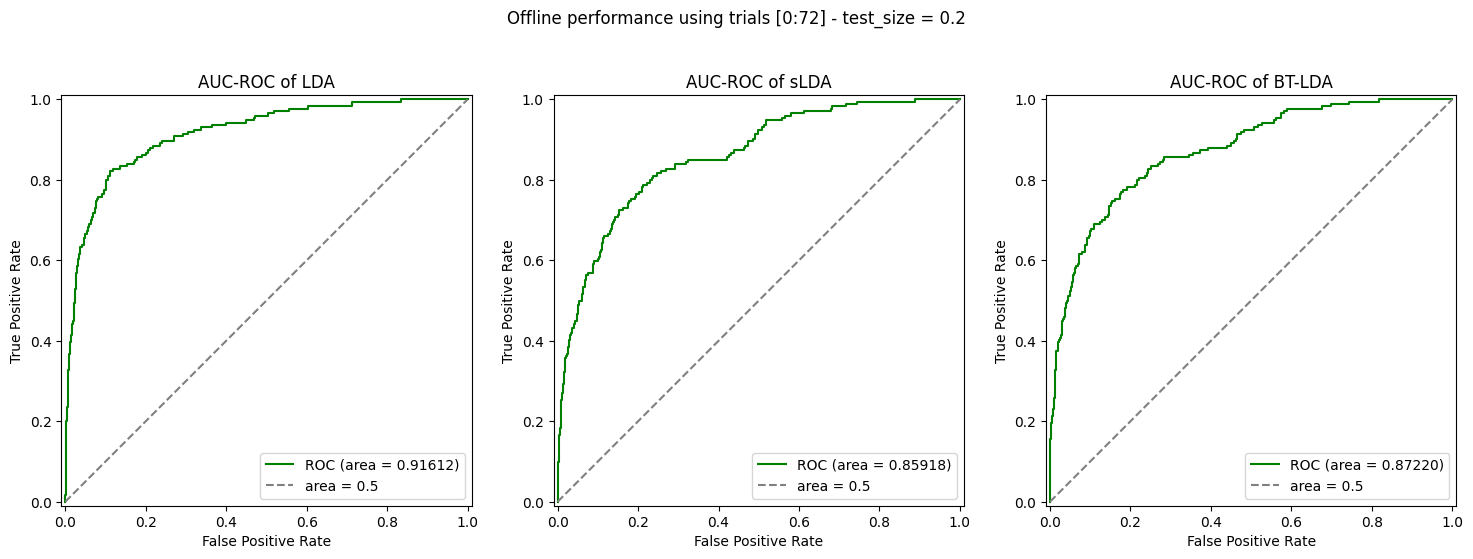

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.9139677785408332
Mean AUC score of sLDA: 	 0.8598612346337464
Mean AUC score of BT-LDA: 	 0.8675093086772213
trial 0/132
trial 1/132
trial 2/132
trial 3/132
trial 4/132
trial 5/132
trial 6/132
trial 7/132
trial 8/132
trial 9/132
trial 10/132
trial 11/132
trial 12/132
trial 13/132
trial 14/132
trial 15/132
trial 16/132
trial 17/132
trial 18/132
trial 19/132
trial 20/132
trial 21/132
trial 22/132
trial 23/132
trial 24/132
trial 25/132
trial 26/132
trial 27/132
trial 28/132
trial 29/132
trial 30/132
trial 31/132
trial 32/132
trial 33/132
trial 34/132
trial 35/132
trial 36/132
trial 37/132
trial 38/132
trial 39/132
trial 40/132
trial 41/132
trial 42/132
trial 43/132
trial 44/132
trial 45/132
trial 46/132
trial 47/132
trial 48/132
trial 49/132
trial 50/132
trial 51/132
trial 52/132
trial 53/132
trial 54/132
trial 55/132
trial 56/132
trial 57/132
trial 58/132
trial 59/132
trial 60/132
trial 61/132
trial 62/132
tr

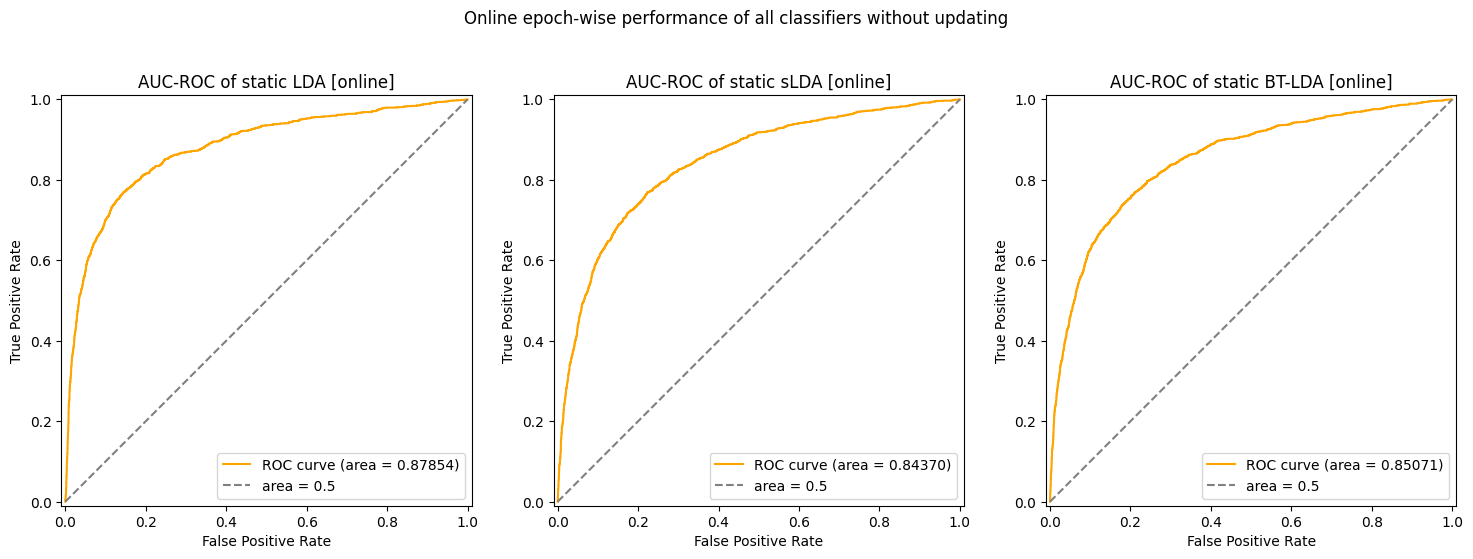

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.98485
Accuracy SLDA: 0.99242
Accuracy BT-LDA: 0.99242
trial 0/132
trial 1/132
trial 2/132
trial 3/132
trial 4/132
trial 5/132
trial 6/132
trial 7/132
trial 8/132
trial 9/132
trial 10/132
trial 11/132
trial 12/132
trial 13/132
trial 14/132
trial 15/132
trial 16/132
trial 17/132
trial 18/132
trial 19/132
trial 20/132
trial 21/132
trial 22/132
trial 23/132
trial 24/132
trial 25/132
trial 26/132
trial 27/132
trial 28/132
trial 29/132
trial 30/132
trial 31/132
trial 32/132
trial 33/132
trial 34/132
trial 35/132
trial 36/132
trial 37/132
trial 38/132
trial 39/132
trial 40/132
trial 41/132
trial 42/132
trial 43/132
trial 44/132
trial 45/132
trial 46/132
trial 47/132
trial 48/132
trial 49/132
trial 50/132
trial 51/132
trial 52/132
trial 53/132
trial 54/132
trial 55/132
trial 56/132
trial 57/132
trial 58/132
trial 59/132
trial 60/132
trial 61/132
trial 62/132
trial 63/132
trial 64/132
trial 65/132
tria

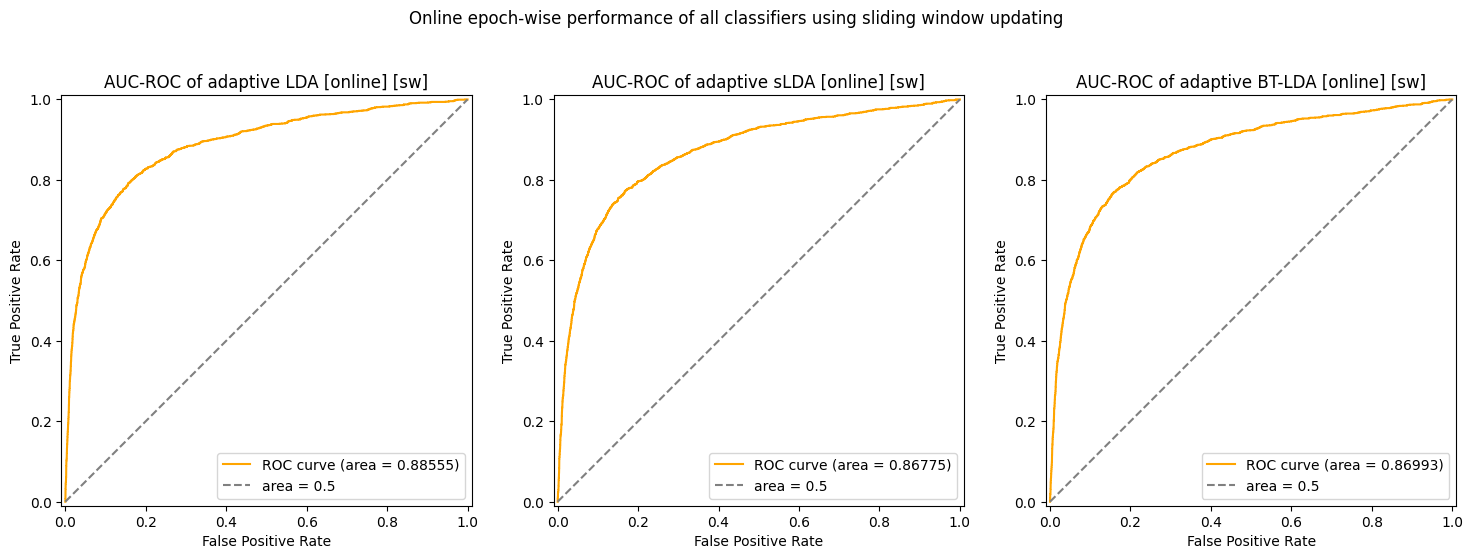

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.99242
Accuracy SLDA: 0.98485
Accuracy BT-LDA: 0.99242
Loading file:  data_p3_P3_S7_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S7_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S7_anonymized.pkl
Loading file:  data_p3_P3_S8_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S8_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S8_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 11.33333333 15.33333333 15.33333333 12.16666667]
Run 2: [15.33333333 14.33333333 15.33333333 15.33333333 15.33333333 15.16666667]
Run 3: [15.33333333 11.33333333 15.33333333 15.33333333  8.33333333 15.16666667]
Run 4: [15.33333333 12.33333333  8.33333333  8.33333333 12.33333333 15.16666667]
Run 5: [ 9.33333333  9.333333

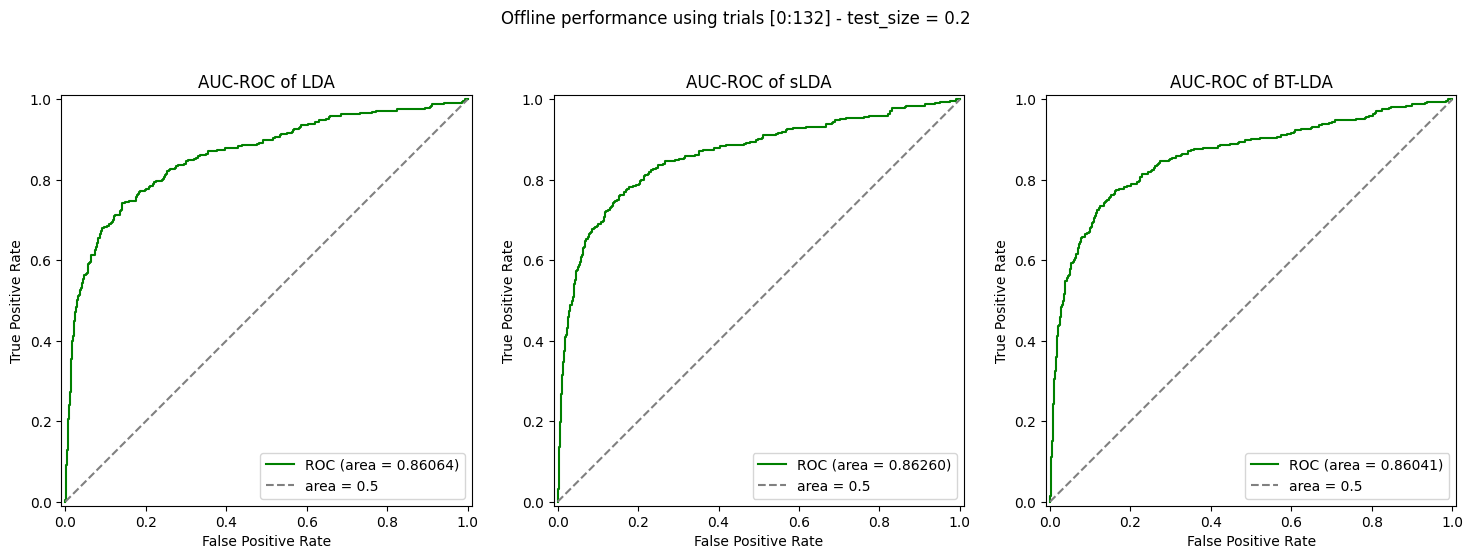

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.88894351157542
Mean AUC score of sLDA: 	 0.8745510491640123
Mean AUC score of BT-LDA: 	 0.8794180196784276
trial 0/132
trial 1/132
trial 2/132
trial 3/132
trial 4/132
trial 5/132
trial 6/132
trial 7/132
trial 8/132
trial 9/132
trial 10/132
trial 11/132
trial 12/132
trial 13/132
trial 14/132
trial 15/132
trial 16/132
trial 17/132
trial 18/132
trial 19/132
trial 20/132
trial 21/132
trial 22/132
trial 23/132
trial 24/132
trial 25/132
trial 26/132
trial 27/132
trial 28/132
trial 29/132
trial 30/132
trial 31/132
trial 32/132
trial 33/132
trial 34/132
trial 35/132
trial 36/132
trial 37/132
trial 38/132
trial 39/132
trial 40/132
trial 41/132
trial 42/132
trial 43/132
trial 44/132
trial 45/132
trial 46/132
trial 47/132
trial 48/132
trial 49/132
trial 50/132
trial 51/132
trial 52/132
trial 53/132
trial 54/132
trial 55/132
trial 56/132
trial 57/132
trial 58/132
trial 59/132
trial 60/132
trial 61/132
trial 62/132
tria

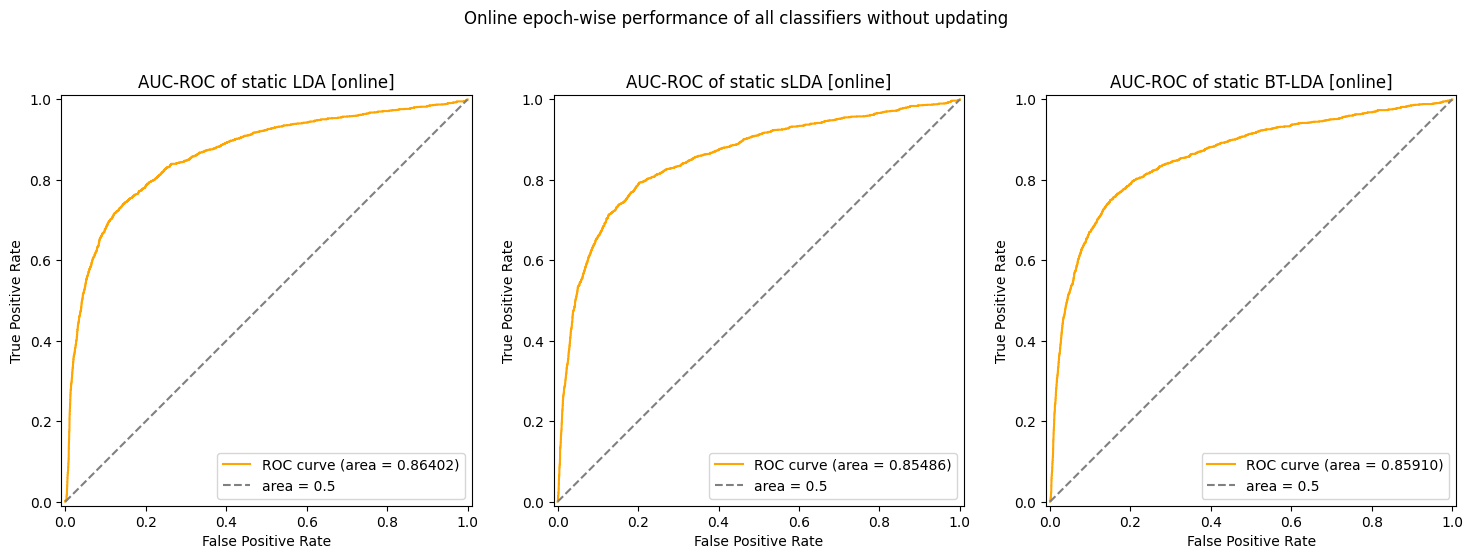

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.93939
Accuracy SLDA: 0.93939
Accuracy BT-LDA: 0.93182
trial 0/132
trial 1/132
trial 2/132
trial 3/132
trial 4/132
trial 5/132
trial 6/132
trial 7/132
trial 8/132
trial 9/132
trial 10/132
trial 11/132
trial 12/132
trial 13/132
trial 14/132
trial 15/132
trial 16/132
trial 17/132
trial 18/132
trial 19/132
trial 20/132
trial 21/132
trial 22/132
trial 23/132
trial 24/132
trial 25/132
trial 26/132
trial 27/132
trial 28/132
trial 29/132
trial 30/132
trial 31/132
trial 32/132
trial 33/132
trial 34/132
trial 35/132
trial 36/132
trial 37/132
trial 38/132
trial 39/132
trial 40/132
trial 41/132
trial 42/132
trial 43/132
trial 44/132
trial 45/132
trial 46/132
trial 47/132
trial 48/132
trial 49/132
trial 50/132
trial 51/132
trial 52/132
trial 53/132
trial 54/132
trial 55/132
trial 56/132
trial 57/132
trial 58/132
trial 59/132
trial 60/132
trial 61/132
trial 62/132
trial 63/132
trial 64/132
trial 65/132
tria

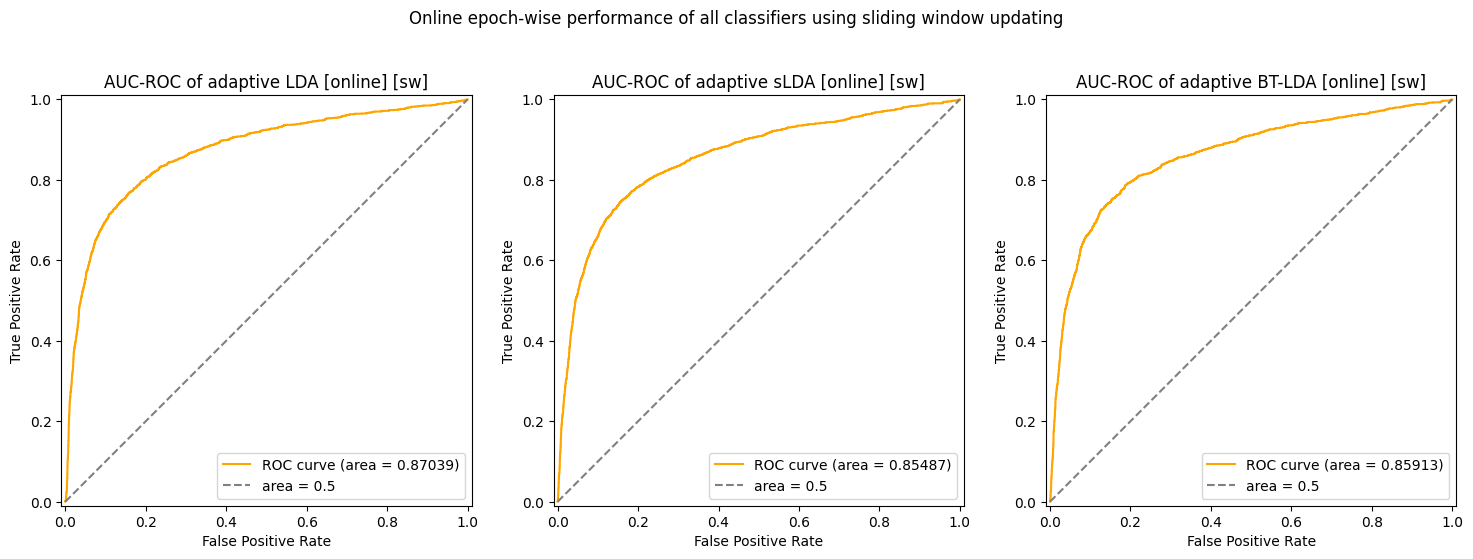

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.93182
Accuracy SLDA: 0.93182
Accuracy BT-LDA: 0.93182
Loading file:  data_p3_P3_S8_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S8_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S8_anonymized.pkl
Loading file:  data_p3_P3_S9_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S9_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S9_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333  8.33333333 15.33333333 15.33333333 15.33333333 15.16666667]
Run 2: [15.33333333 15.33333333 15.33333333 15.33333333 15.33333333  8.16666667]
Run 3: [15.33333333  8.33333333  9.33333333 10.33333333 11.33333333 15.16666667]
Run 4: [15.33333333 15.33333333  8.33333333 15.33333333  9.33333333 12.16666667]
Run 5: [15.5        13.333333

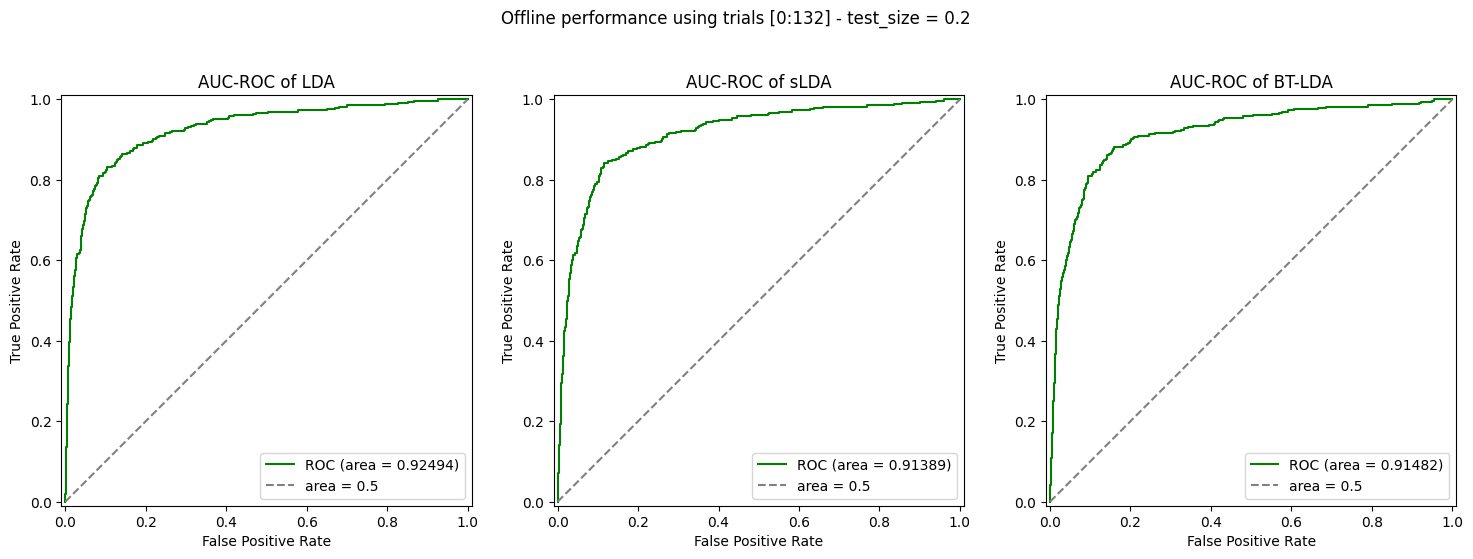

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.8726549309715464
Mean AUC score of sLDA: 	 0.857031979846465
Mean AUC score of BT-LDA: 	 0.8605402463432873
trial 0/96
trial 1/96
trial 2/96
trial 3/96
trial 4/96
trial 5/96
trial 6/96
trial 7/96
trial 8/96
trial 9/96
trial 10/96
trial 11/96
trial 12/96
trial 13/96
trial 14/96
trial 15/96
trial 16/96
trial 17/96
trial 18/96
trial 19/96
trial 20/96
trial 21/96
trial 22/96
trial 23/96
trial 24/96
trial 25/96
trial 26/96
trial 27/96
trial 28/96
trial 29/96
trial 30/96
trial 31/96
trial 32/96
trial 33/96
trial 34/96
trial 35/96
trial 36/96
trial 37/96
trial 38/96
trial 39/96
trial 40/96
trial 41/96
trial 42/96
trial 43/96
trial 44/96
trial 45/96
trial 46/96
trial 47/96
trial 48/96
trial 49/96
trial 50/96
trial 51/96
trial 52/96
trial 53/96
trial 54/96
trial 55/96
trial 56/96
trial 57/96
trial 58/96
trial 59/96
trial 60/96
trial 61/96
trial 62/96
trial 63/96
trial 64/96
trial 65/96
trial 66/96
trial 67/96
trial 

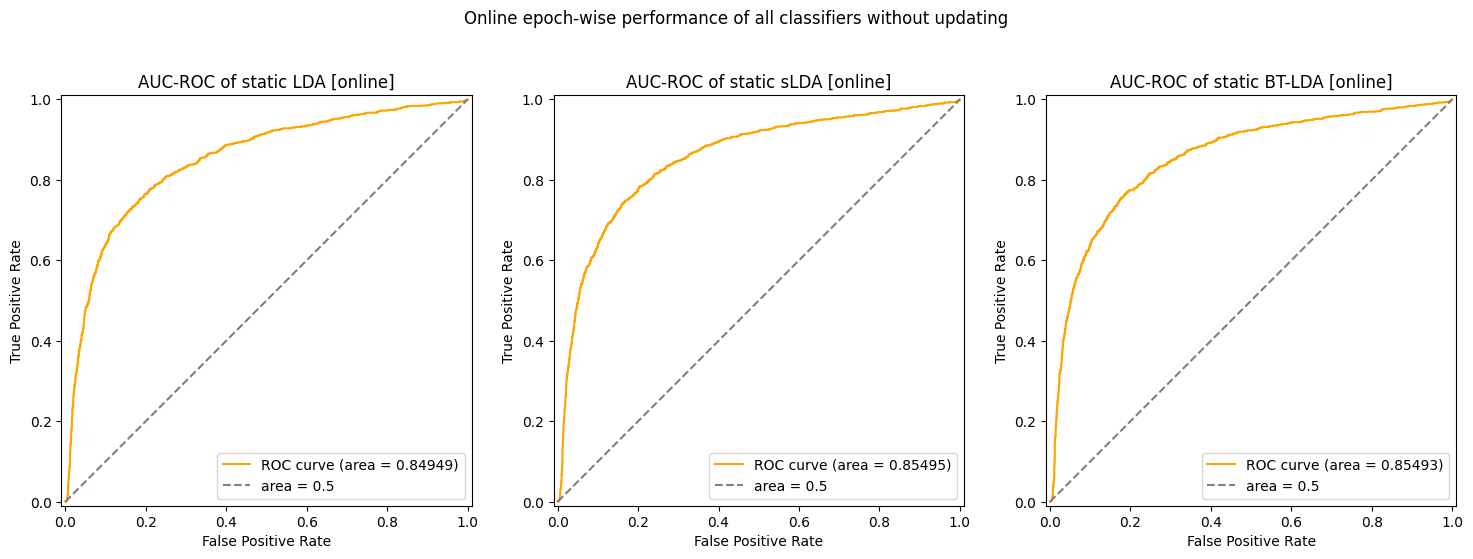

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.92708
Accuracy SLDA: 0.92708
Accuracy BT-LDA: 0.94792
trial 0/96
trial 1/96
trial 2/96
trial 3/96
trial 4/96
trial 5/96
trial 6/96
trial 7/96
trial 8/96
trial 9/96
trial 10/96
trial 11/96
trial 12/96
trial 13/96
trial 14/96
trial 15/96
trial 16/96
trial 17/96
trial 18/96
trial 19/96
trial 20/96
trial 21/96
trial 22/96
trial 23/96
trial 24/96
trial 25/96
trial 26/96
trial 27/96
trial 28/96
trial 29/96
trial 30/96
trial 31/96
trial 32/96
trial 33/96
trial 34/96
trial 35/96
trial 36/96
trial 37/96
trial 38/96
trial 39/96
trial 40/96
trial 41/96
trial 42/96
trial 43/96
trial 44/96
trial 45/96
trial 46/96
trial 47/96
trial 48/96
trial 49/96
trial 50/96
trial 51/96
trial 52/96
trial 53/96
trial 54/96
trial 55/96
trial 56/96
trial 57/96
trial 58/96
trial 59/96
trial 60/96
trial 61/96
trial 62/96
trial 63/96
trial 64/96
trial 65/96
trial 66/96
trial 67/96
trial 68/96
trial 69/96
trial 70/96
trial 71/9

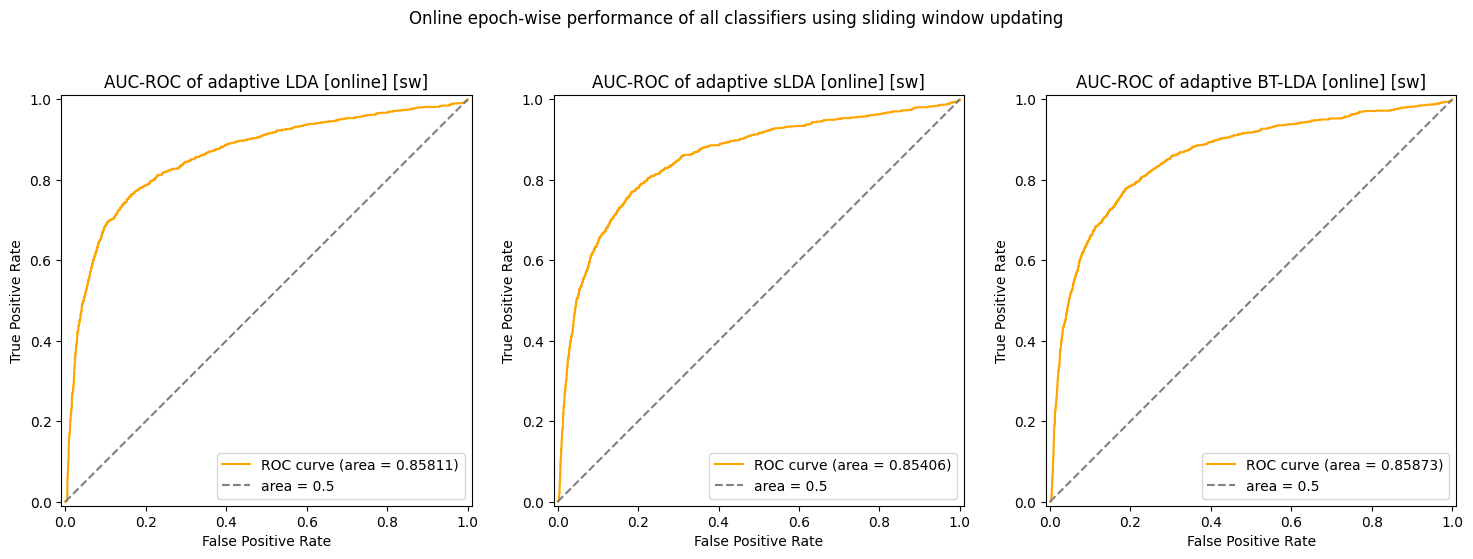

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.93750
Accuracy SLDA: 0.94792
Accuracy BT-LDA: 0.93750
Loading file:  data_p3_P3_S9_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S9_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S9_anonymized.pkl
Loading file:  data_p3_P3_S10_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S10_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S10_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 15.33333333 15.33333333  9.33333333 14.16666667]
Run 2: [ 9.33333333 10.33333333 13.33333333 15.33333333 15.33333333 11.16666667]
Run 3: [11.33333333 11.33333333 11.5        10.33333333 15.33333333 15.16666667]
Run 4: [ 9.33333333 10.33333333 15.33333333 10.5        10.33333333 11.16666667]
Run 5: [11.33333333  8.333

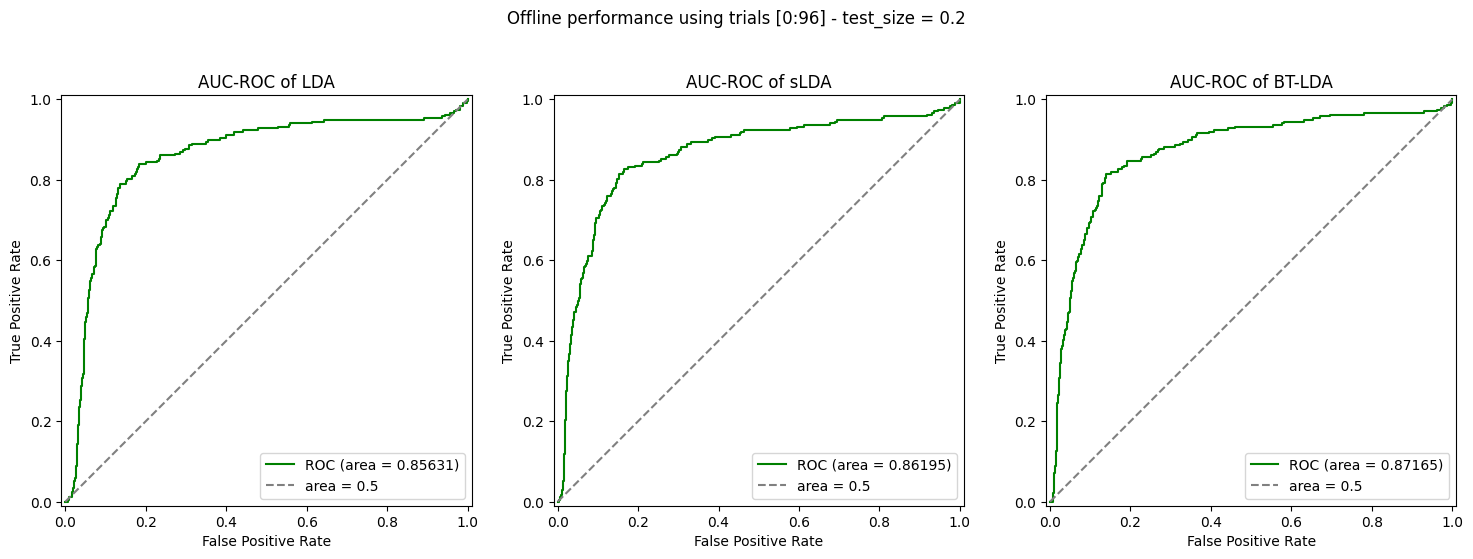

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.8535159103360117
Mean AUC score of sLDA: 	 0.8346203889700512
Mean AUC score of BT-LDA: 	 0.8440553095325054
trial 0/144
trial 1/144
trial 2/144
trial 3/144
trial 4/144
trial 5/144
trial 6/144
trial 7/144
trial 8/144
trial 9/144
trial 10/144
trial 11/144
trial 12/144
trial 13/144
trial 14/144
trial 15/144
trial 16/144
trial 17/144
trial 18/144
trial 19/144
trial 20/144
trial 21/144
trial 22/144
trial 23/144
trial 24/144
trial 25/144
trial 26/144
trial 27/144
trial 28/144
trial 29/144
trial 30/144
trial 31/144
trial 32/144
trial 33/144
trial 34/144
trial 35/144
trial 36/144
trial 37/144
trial 38/144
trial 39/144
trial 40/144
trial 41/144
trial 42/144
trial 43/144
trial 44/144
trial 45/144
trial 46/144
trial 47/144
trial 48/144
trial 49/144
trial 50/144
trial 51/144
trial 52/144
trial 53/144
trial 54/144
trial 55/144
trial 56/144
trial 57/144
trial 58/144
trial 59/144
trial 60/144
trial 61/144
trial 62/144
tr

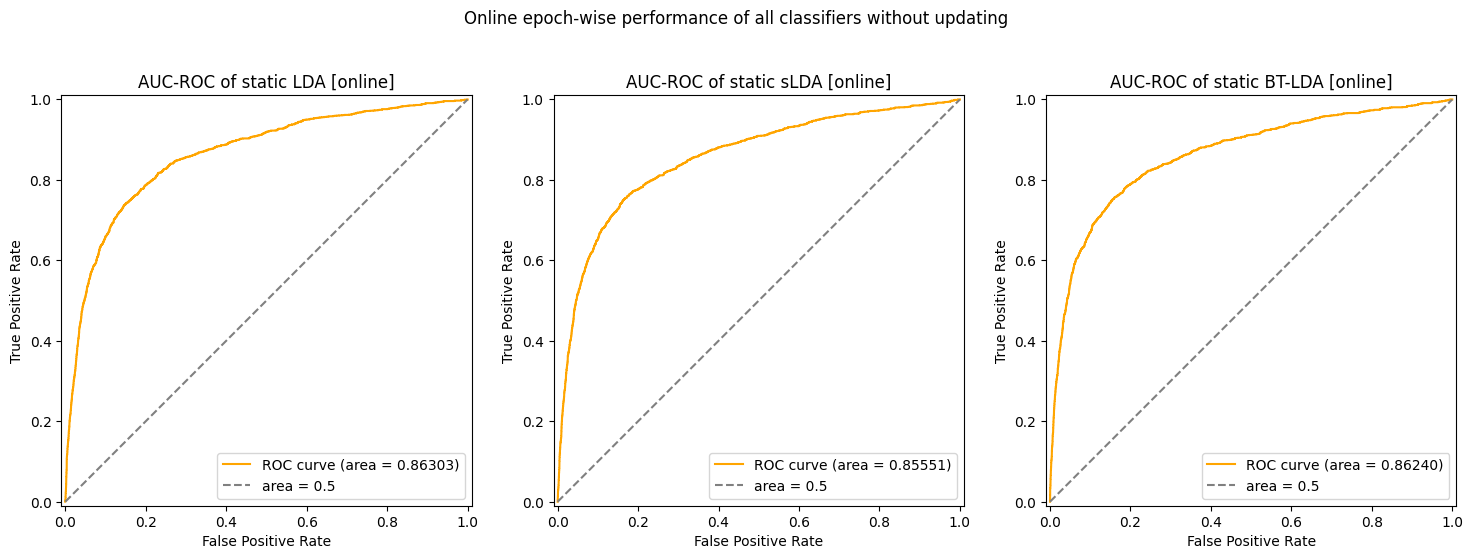

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.97917
Accuracy SLDA: 0.97917
Accuracy BT-LDA: 0.97222
trial 0/144
trial 1/144
trial 2/144
trial 3/144
trial 4/144
trial 5/144
trial 6/144
trial 7/144
trial 8/144
trial 9/144
trial 10/144
trial 11/144
trial 12/144
trial 13/144
trial 14/144
trial 15/144
trial 16/144
trial 17/144
trial 18/144
trial 19/144
trial 20/144
trial 21/144
trial 22/144
trial 23/144
trial 24/144
trial 25/144
trial 26/144
trial 27/144
trial 28/144
trial 29/144
trial 30/144
trial 31/144
trial 32/144
trial 33/144
trial 34/144
trial 35/144
trial 36/144
trial 37/144
trial 38/144
trial 39/144
trial 40/144
trial 41/144
trial 42/144
trial 43/144
trial 44/144
trial 45/144
trial 46/144
trial 47/144
trial 48/144
trial 49/144
trial 50/144
trial 51/144
trial 52/144
trial 53/144
trial 54/144
trial 55/144
trial 56/144
trial 57/144
trial 58/144
trial 59/144
trial 60/144
trial 61/144
trial 62/144
trial 63/144
trial 64/144
trial 65/144
tria

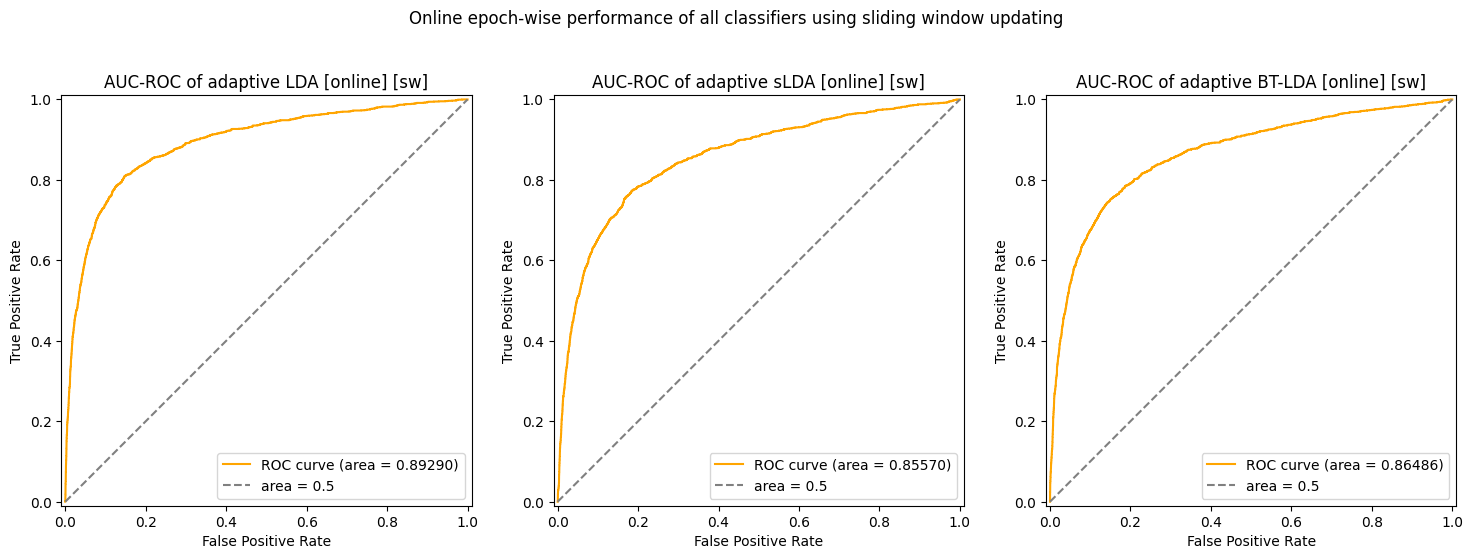

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.97917
Accuracy SLDA: 0.97917
Accuracy BT-LDA: 0.97222
Loading file:  data_p3_P3_S10_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S10_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S10_anonymized.pkl
Loading file:  data_p3_P3_S11_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S11_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S11_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 14.33333333 15.33333333 15.33333333  8.16666667]
Run 2: [15.33333333  8.33333333 15.33333333 15.33333333 15.33333333  8.16666667]
Run 3: [ 8.33333333 15.33333333  8.33333333 13.33333333 15.33333333 15.16666667]
Run 4: [ 8.33333333  8.33333333 15.33333333  8.33333333  8.33333333  8.16666667]
Run 5: [ 8.33333333 11.

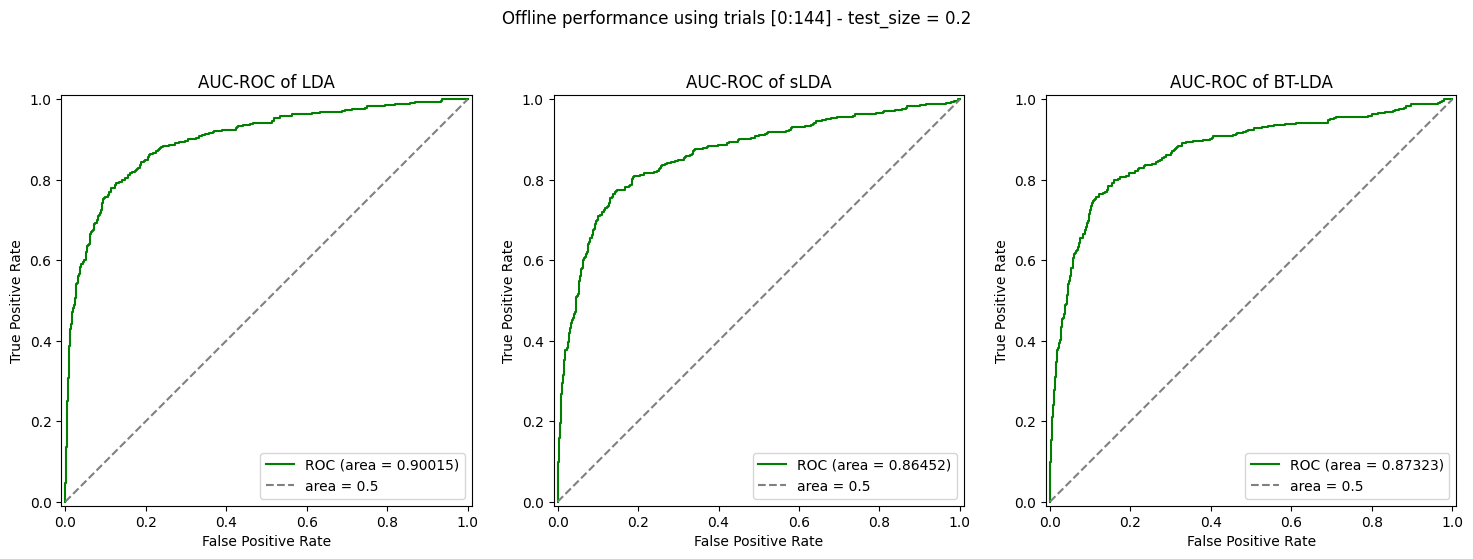

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.8998116741015065
Mean AUC score of sLDA: 	 0.8572297681171619
Mean AUC score of BT-LDA: 	 0.8686921345004629
trial 0/150
trial 1/150
trial 2/150
trial 3/150
trial 4/150
trial 5/150
trial 6/150
trial 7/150
trial 8/150
trial 9/150
trial 10/150
trial 11/150
trial 12/150
trial 13/150
trial 14/150
trial 15/150
trial 16/150
trial 17/150
trial 18/150
trial 19/150
trial 20/150
trial 21/150
trial 22/150
trial 23/150
trial 24/150
trial 25/150
trial 26/150
trial 27/150
trial 28/150
trial 29/150
trial 30/150
trial 31/150
trial 32/150
trial 33/150
trial 34/150
trial 35/150
trial 36/150
trial 37/150
trial 38/150
trial 39/150
trial 40/150
trial 41/150
trial 42/150
trial 43/150
trial 44/150
trial 45/150
trial 46/150
trial 47/150
trial 48/150
trial 49/150
trial 50/150
trial 51/150
trial 52/150
trial 53/150
trial 54/150
trial 55/150
trial 56/150
trial 57/150
trial 58/150
trial 59/150
trial 60/150
trial 61/150
trial 62/150
tr

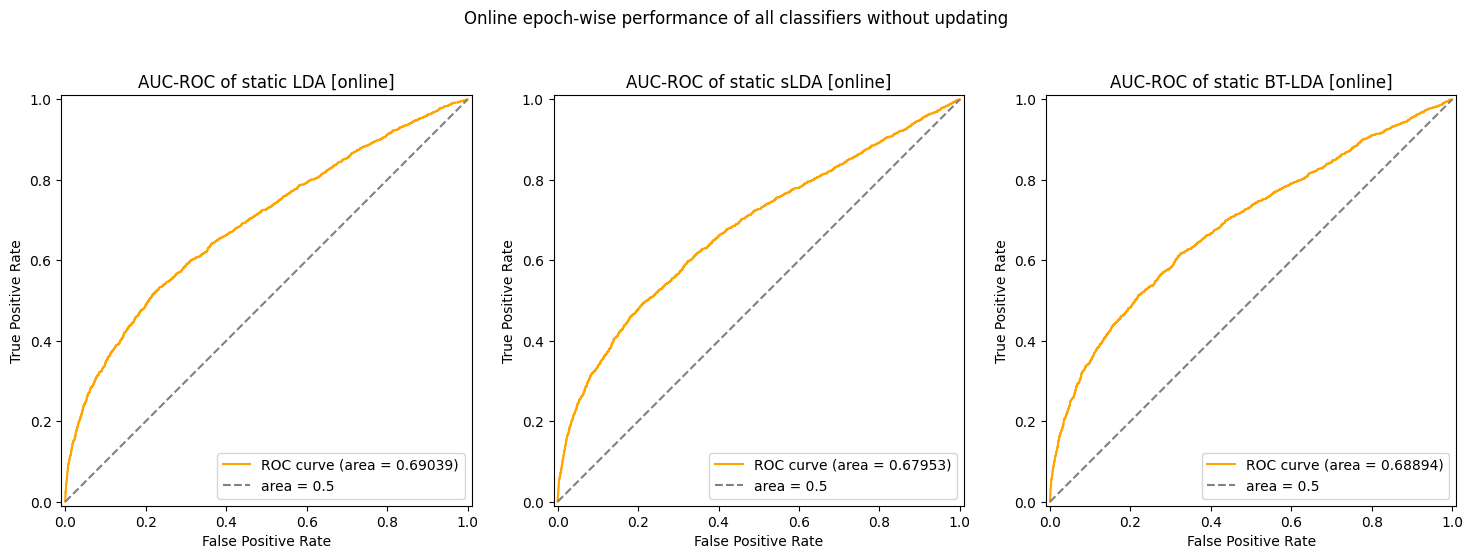

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.73333
Accuracy SLDA: 0.71333
Accuracy BT-LDA: 0.75333
trial 0/150
trial 1/150
trial 2/150
trial 3/150
trial 4/150
trial 5/150
trial 6/150
trial 7/150
trial 8/150
trial 9/150
trial 10/150
trial 11/150
trial 12/150
trial 13/150
trial 14/150
trial 15/150
trial 16/150
trial 17/150
trial 18/150
trial 19/150
trial 20/150
trial 21/150
trial 22/150
trial 23/150
trial 24/150
trial 25/150
trial 26/150
trial 27/150
trial 28/150
trial 29/150
trial 30/150
trial 31/150
trial 32/150
trial 33/150
trial 34/150
trial 35/150
trial 36/150
trial 37/150
trial 38/150
trial 39/150
trial 40/150
trial 41/150
trial 42/150
trial 43/150
trial 44/150
trial 45/150
trial 46/150
trial 47/150
trial 48/150
trial 49/150
trial 50/150
trial 51/150
trial 52/150
trial 53/150
trial 54/150
trial 55/150
trial 56/150
trial 57/150
trial 58/150
trial 59/150
trial 60/150
trial 61/150
trial 62/150
trial 63/150
trial 64/150
trial 65/150
tria

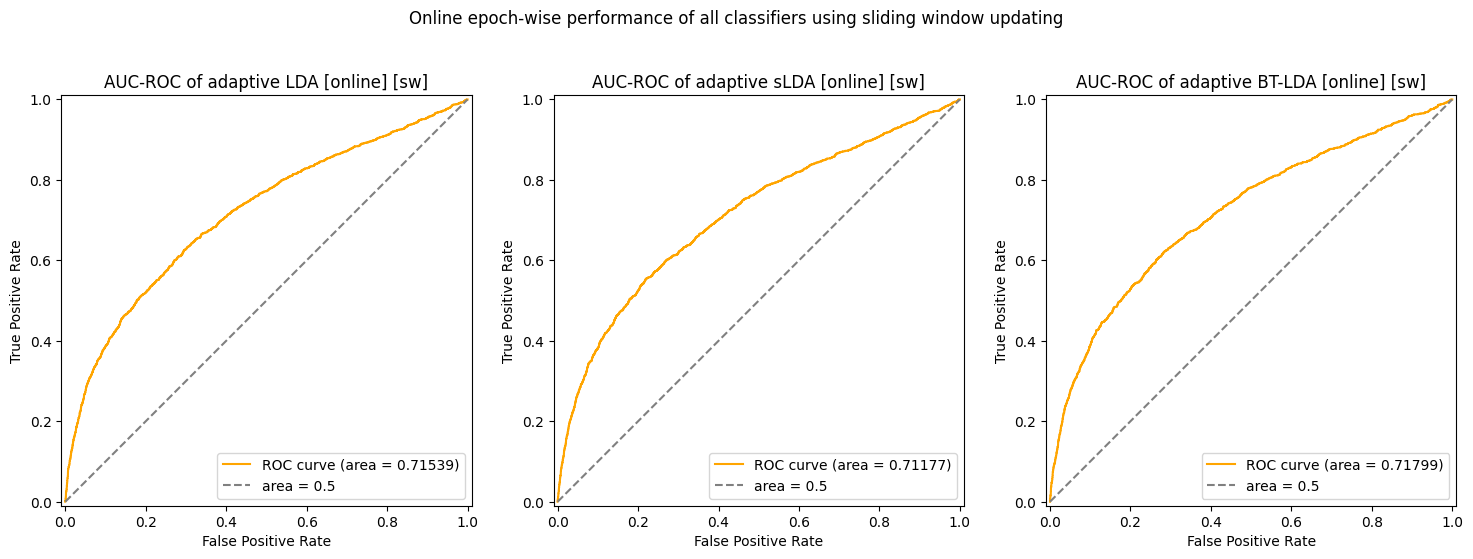

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.79333
Accuracy SLDA: 0.80000
Accuracy BT-LDA: 0.81333
Loading file:  data_p3_P3_S11_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S11_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S11_anonymized.pkl
Loading file:  data_p3_P3_S12_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S12_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S12_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [ 8.33333333  8.33333333 15.33333333  8.33333333 15.33333333 14.16666667]
Run 2: [ 8.33333333  8.33333333 15.33333333 15.33333333 13.33333333  8.16666667]
Run 3: [ 8.33333333 15.33333333  8.33333333  9.33333333  8.33333333 15.16666667]
Run 4: [15.33333333 10.33333333 10.33333333  8.33333333  8.33333333 15.16666667]
Run 5: [ 8.33333333  8.

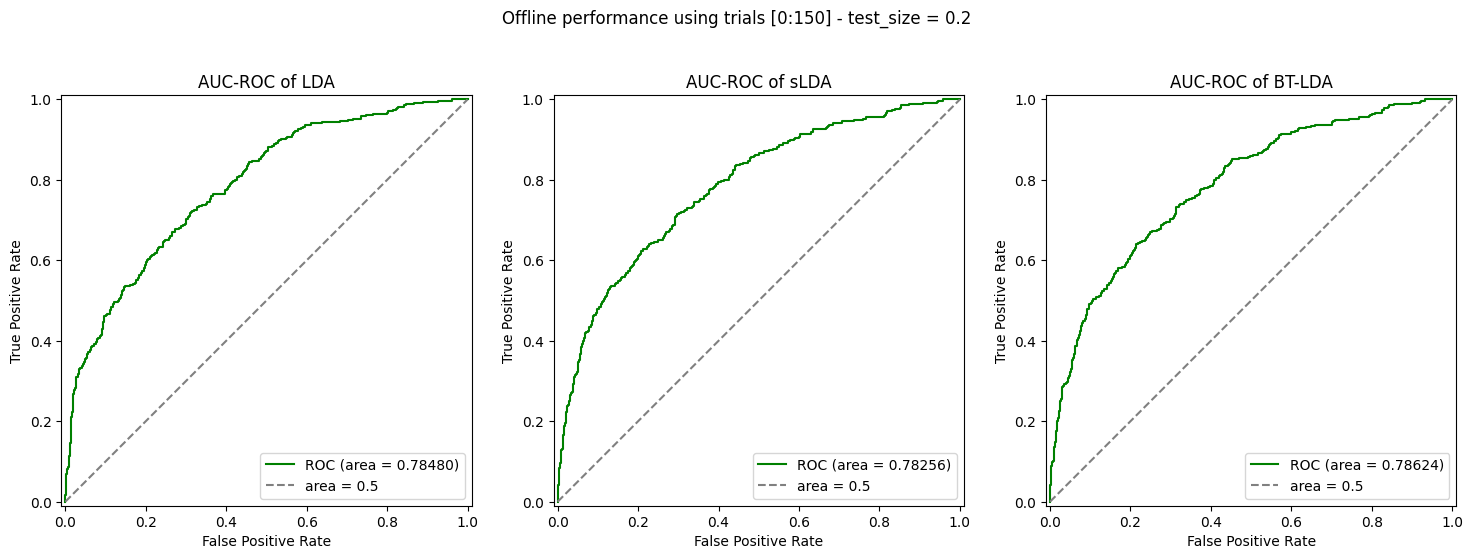

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.7440402481188875
Mean AUC score of sLDA: 	 0.7423661861119497
Mean AUC score of BT-LDA: 	 0.744974396363657
trial 0/150
trial 1/150
trial 2/150
trial 3/150
trial 4/150
trial 5/150
trial 6/150
trial 7/150
trial 8/150
trial 9/150
trial 10/150
trial 11/150
trial 12/150
trial 13/150
trial 14/150
trial 15/150
trial 16/150
trial 17/150
trial 18/150
trial 19/150
trial 20/150
trial 21/150
trial 22/150
trial 23/150
trial 24/150
trial 25/150
trial 26/150
trial 27/150
trial 28/150
trial 29/150
trial 30/150
trial 31/150
trial 32/150
trial 33/150
trial 34/150
trial 35/150
trial 36/150
trial 37/150
trial 38/150
trial 39/150
trial 40/150
trial 41/150
trial 42/150
trial 43/150
trial 44/150
trial 45/150
trial 46/150
trial 47/150
trial 48/150
trial 49/150
trial 50/150
trial 51/150
trial 52/150
trial 53/150
trial 54/150
trial 55/150
trial 56/150
trial 57/150
trial 58/150
trial 59/150
trial 60/150
trial 61/150
trial 62/150
tri

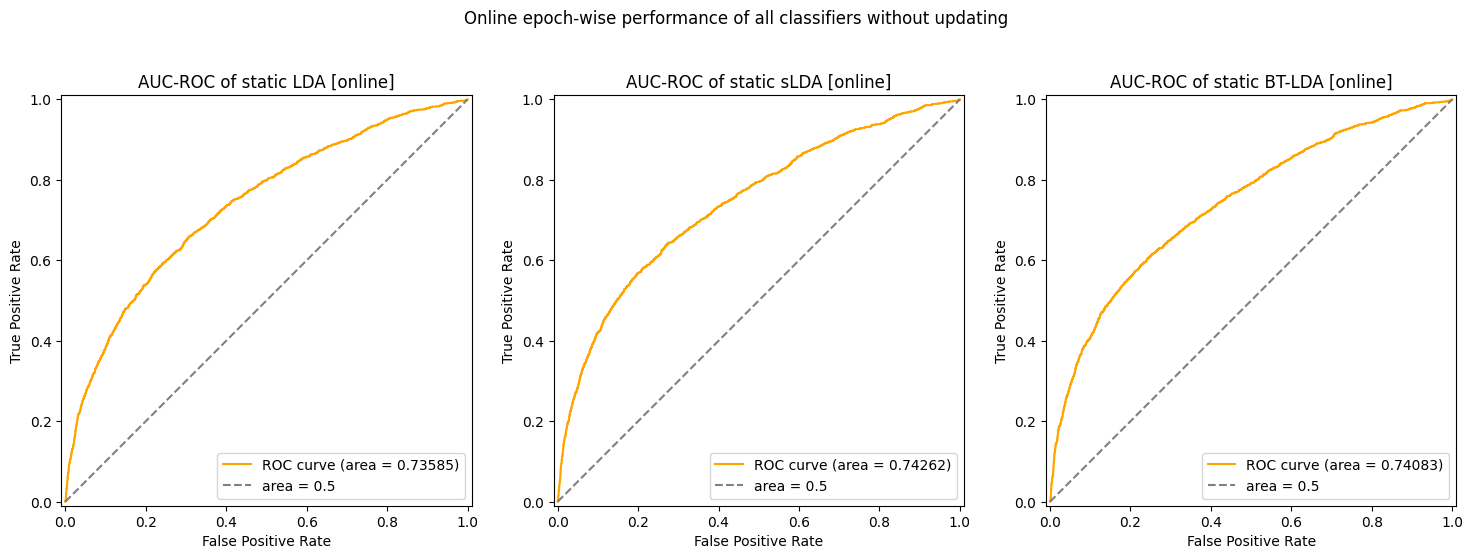

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.85333
Accuracy SLDA: 0.85333
Accuracy BT-LDA: 0.84667
trial 0/150
trial 1/150
trial 2/150
trial 3/150
trial 4/150
trial 5/150
trial 6/150
trial 7/150
trial 8/150
trial 9/150
trial 10/150
trial 11/150
trial 12/150
trial 13/150
trial 14/150
trial 15/150
trial 16/150
trial 17/150
trial 18/150
trial 19/150
trial 20/150
trial 21/150
trial 22/150
trial 23/150
trial 24/150
trial 25/150
trial 26/150
trial 27/150
trial 28/150
trial 29/150
trial 30/150
trial 31/150
trial 32/150
trial 33/150
trial 34/150
trial 35/150
trial 36/150
trial 37/150
trial 38/150
trial 39/150
trial 40/150
trial 41/150
trial 42/150
trial 43/150
trial 44/150
trial 45/150
trial 46/150
trial 47/150
trial 48/150
trial 49/150
trial 50/150
trial 51/150
trial 52/150
trial 53/150
trial 54/150
trial 55/150
trial 56/150
trial 57/150
trial 58/150
trial 59/150
trial 60/150
trial 61/150
trial 62/150
trial 63/150
trial 64/150
trial 65/150
tria

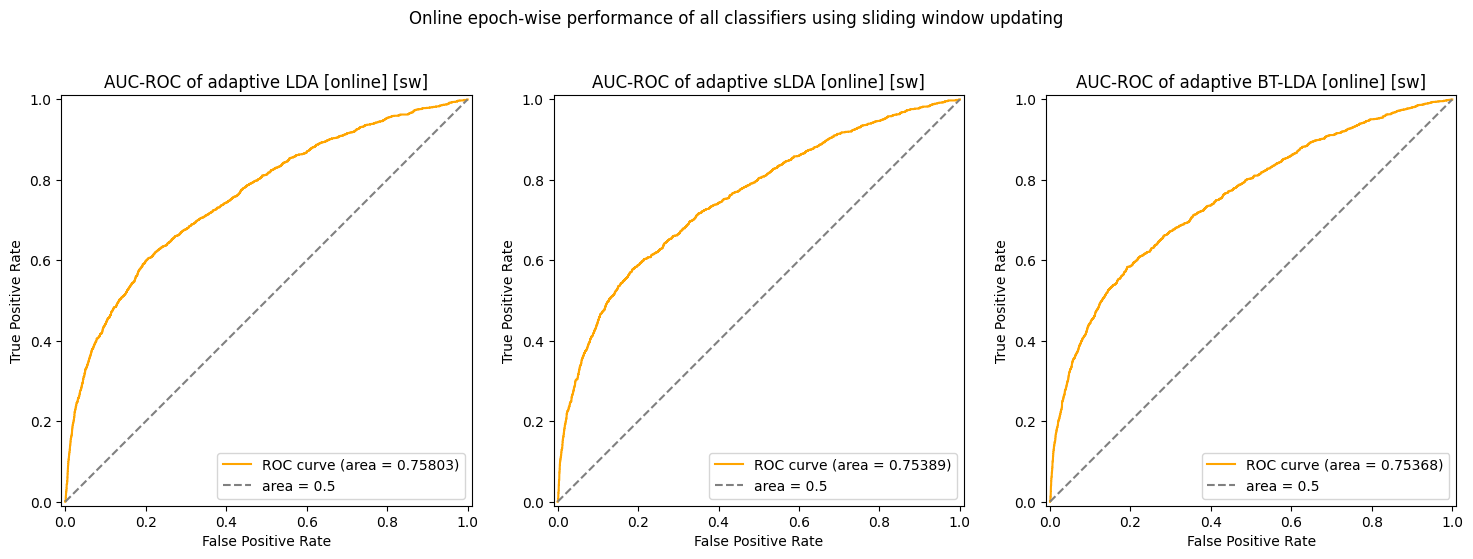

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.86667
Accuracy SLDA: 0.88000
Accuracy BT-LDA: 0.87333
Loading file:  data_p3_P3_S12_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S12_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S12_anonymized.pkl
Loading file:  data_p3_P3_S13_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S13_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S13_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [ 8.33333333  8.33333333 15.33333333 10.33333333 15.33333333  9.16666667]
Run 2: [ 8.33333333 15.33333333 15.33333333  8.33333333 10.33333333 15.16666667]
Run 3: [14.33333333 15.33333333  8.33333333  9.33333333  9.33333333  9.33333333]
Run 4: [10.33333333 11.33333333 15.33333333  8.33333333  8.33333333 11.16666667]
Run 5: [15.33333333  8.

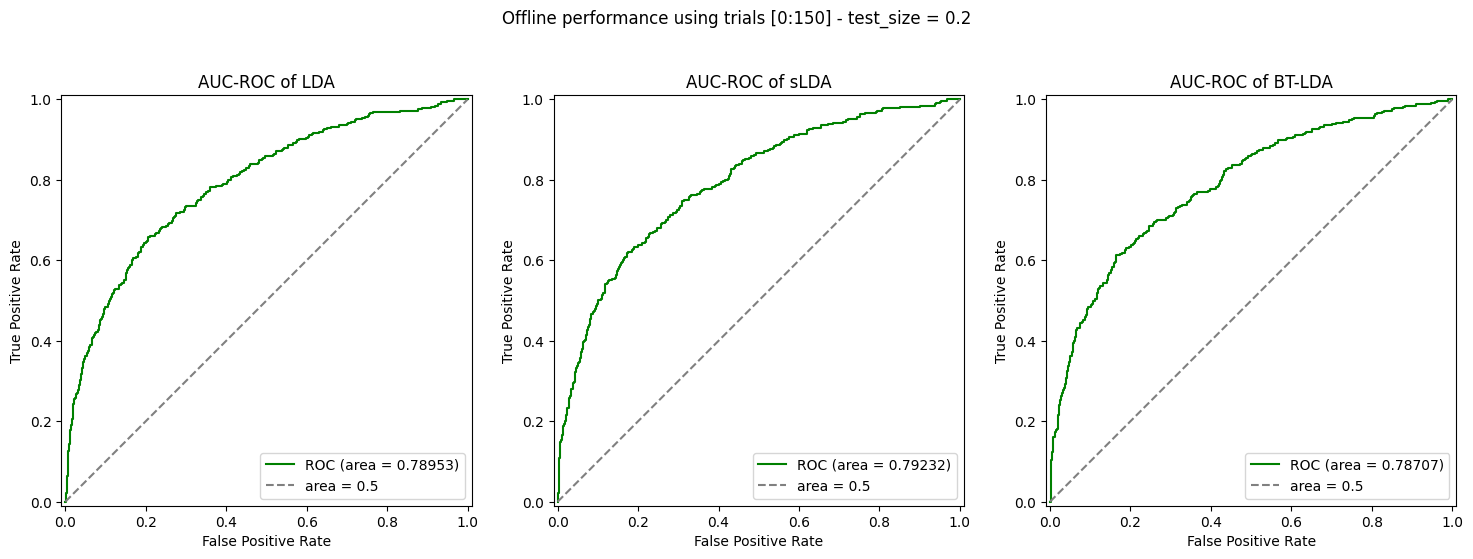

AUC scores computed using a 4-fold cross-validation
Mean AUC score of LDA: 		 0.7547257132756091
Mean AUC score of sLDA: 	 0.7525310835300354
Mean AUC score of BT-LDA: 	 0.7519392730040853
trial 0/156
trial 1/156
trial 2/156
trial 3/156
trial 4/156
trial 5/156
trial 6/156
trial 7/156
trial 8/156
trial 9/156
trial 10/156
trial 11/156
trial 12/156
trial 13/156
trial 14/156
trial 15/156
trial 16/156
trial 17/156
trial 18/156
trial 19/156
trial 20/156
trial 21/156
trial 22/156
trial 23/156
trial 24/156
trial 25/156
trial 26/156
trial 27/156
trial 28/156
trial 29/156
trial 30/156
trial 31/156
trial 32/156
trial 33/156
trial 34/156
trial 35/156
trial 36/156
trial 37/156
trial 38/156
trial 39/156
trial 40/156
trial 41/156
trial 42/156
trial 43/156
trial 44/156
trial 45/156
trial 46/156
trial 47/156
trial 48/156
trial 49/156
trial 50/156
trial 51/156
trial 52/156
trial 53/156
trial 54/156
trial 55/156
trial 56/156
trial 57/156
trial 58/156
trial 59/156
trial 60/156
trial 61/156
trial 62/156
tr

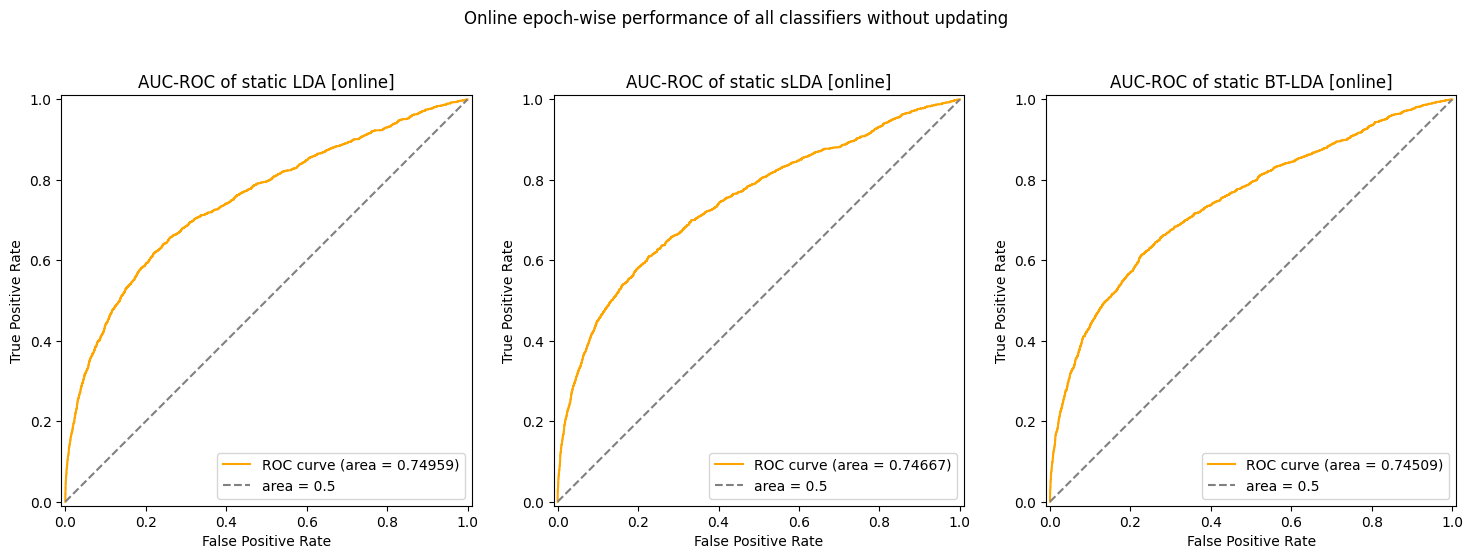

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.87179
Accuracy SLDA: 0.87821
Accuracy BT-LDA: 0.87821
trial 0/156
trial 1/156
trial 2/156
trial 3/156
trial 4/156
trial 5/156
trial 6/156
trial 7/156
trial 8/156
trial 9/156
trial 10/156
trial 11/156
trial 12/156
trial 13/156
trial 14/156
trial 15/156
trial 16/156
trial 17/156
trial 18/156
trial 19/156
trial 20/156
trial 21/156
trial 22/156
trial 23/156
trial 24/156
trial 25/156
trial 26/156
trial 27/156
trial 28/156
trial 29/156
trial 30/156
trial 31/156
trial 32/156
trial 33/156
trial 34/156
trial 35/156
trial 36/156
trial 37/156
trial 38/156
trial 39/156
trial 40/156
trial 41/156
trial 42/156
trial 43/156
trial 44/156
trial 45/156
trial 46/156
trial 47/156
trial 48/156
trial 49/156
trial 50/156
trial 51/156
trial 52/156
trial 53/156
trial 54/156
trial 55/156
trial 56/156
trial 57/156
trial 58/156
trial 59/156
trial 60/156
trial 61/156
trial 62/156
trial 63/156
trial 64/156
trial 65/156
tria

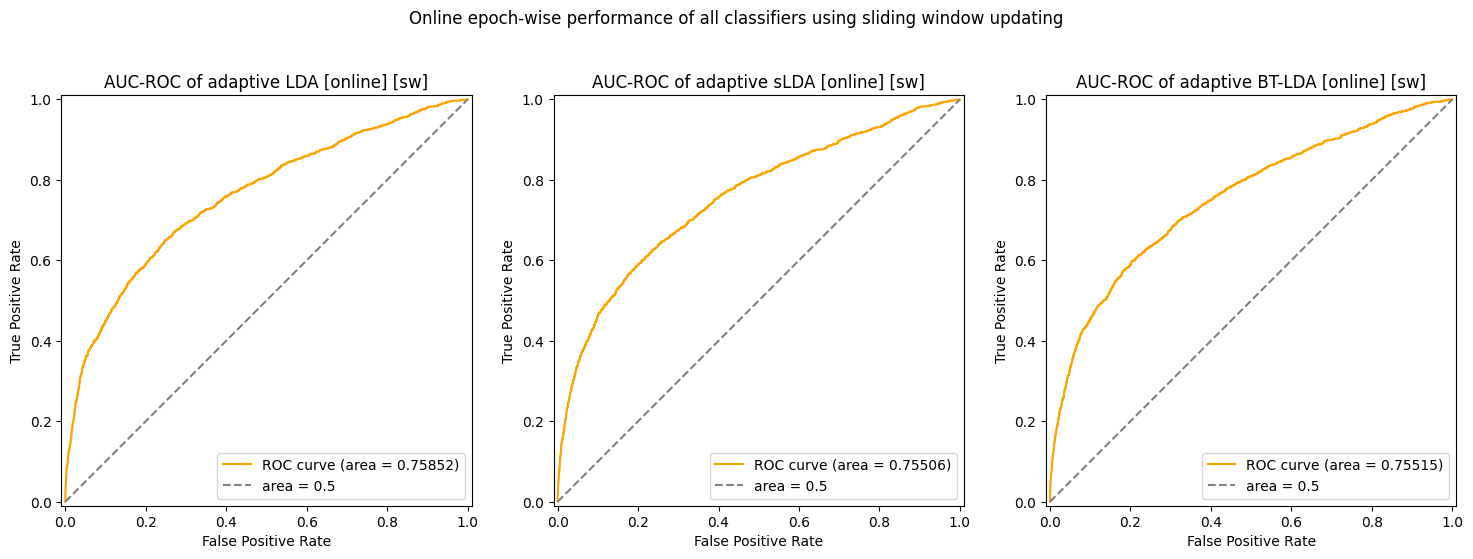

------------------ Word prediction performance (per trial) ------------------
Accuracy LDA: 0.88462
Accuracy SLDA: 0.88462
Accuracy BT-LDA: 0.89103
Loading file:  data_p3_P3_S13_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S13_anonymized.pkl
A .pkl file already exists. Loading the data from cache/data_p3_P3_S13_anonymized.pkl
Loading file:  data_p3_P3_S14_anonymized
Corresponding .pkl file:  cache/data_p3_P3_S14_anonymized.pkl
A .pkl file does not exist yet. Loading the data and creating cache/data_p3_P3_S14_anonymized.pkl... (this might take a few mins)
All conditions of this session are the same:  True
Number of iterations per trial:
Run 1: [15.33333333 15.33333333 15.33333333  8.33333333  8.33333333 11.16666667]
Run 2: [15.33333333  8.33333333 15.33333333 15.33333333 15.33333333 13.16666667]
Run 3: [ 9.33333333 15.33333333 15.33333333 15.33333333 11.33333333 13.16666667]
Run 4: [ 9.33333333 12.33333333  8.33333333 11.33333333  8.33333333  8.16666667]
Run 5: [15.33333333 11.

KeyError: 'Event name "Target" could not be found. The following events are present in the data: Word_1/NonTarget, Word_2/NonTarget, Word_3/NonTarget, Word_4/NonTarget, Word_5/NonTarget'

In [3]:
performances = dict()
for i in range(4,17):
    # 1. Only load the runs of session 8 as training data
    data_train = load_session_chached(f"data_p3/P3_S{i-1}/anonymized")
    trials_train = data_train.get("trials")

    data_test = load_session_chached(f"data_p3/P3_S{i}/anonymized")
    trials_test = data_test.get("trials")

    ppcal = data_train.get('preprocessing')
    fncal = data_train.get('filenames')
    ppon = data_test.get('preprocessing')
    fnon = data_test.get('filenames')

    # 2. Evaluate offline performance 
    clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    compare_auc_single_trial_interval(trials_train, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)
    compute_auc_with_cv(trials_train, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

    # 3. Online simulation static (trained on session i-1 - applied on session i)
    static_result = online_simulation(trials_train, trials_test, log_process=f"p3_online_static_s{i}.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

    # 4. Online simulation with sliding window adaptation (trained on session i-1 - applied on session i)
    adaptive_sw_result = online_adaptation_simulation_sw(trials_train, trials_test, log_process=f"p3_online_adaptive_sw_s{i}.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

    performances.update({f"p3_s{i}_static":static_result})
    performances.update({f"p3_s{i}_adaptive_sw":adaptive_sw_result})

#### Debugging

In [22]:
from utils.preprocessing import load_complete_session
data_info = load_complete_session("data_p3/P3_S14/anonymized", selection="HP_250_Block2_Run4", discard_channels=False)  

['HP']
['250']
All conditions of the selected runs of this session:  True
Number of iterations per trial:
Run 1: [ 9.33333333 15.33333333  9.33333333  8.33333333  8.33333333 10.33333333]
Loaded files: ['P3_S14/anonymized/auditoryAphasia_HP_250_Block2_Run4.vhdr']


KeyError: 'Event name "Target" could not be found. The following events are present in the data: Word_2/NonTarget'

#### save

In [4]:
with open('performances_p3.pkl', 'wb') as f:
    pickle.dump(performances, f)

#### Experiment 3: growing window per session (updating w/o removing data)

##### function

In [ ]:
import logging
import math
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from toeplitzlda.classification import ToeplitzLDA
from utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime
from utils.preprocessing import _have_same_preprocessing, get_n_epochs, get_iteration_structure
from datetime import datetime


def start_logging(log_file_name):
    # this was needed in order to create a log file
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        filename=log_file_name,
        encoding="utf-8",
        filemode="w", # 'a' to not overwrite current log, 'w' to overwrite. This setting can be changed later
        level=logging.DEBUG,
        format='%(message)s')

def close_logging():
    # close and remove all handlers
    logger = logging.getLogger()
    for handler in logger.handlers[:]:
        handler.close()
        logger.removeHandler(handler)

def log_filenames(filenames):
    if filenames is None:
        log_text = "No filenames were given when the training data was passed"
    else:
        log_text = f"data filenames: {filenames}"
    return log_text        

def log_preprocessing(preprocessing_dictionary):
    if preprocessing_dictionary is None:
        text = "No preprocessing configurations were passed..."
    else:    
        text = "------------------------- Preprocessing configurations -------------------------"
        keys = preprocessing_dictionary.keys()
        for key in keys:
            value = preprocessing_dictionary.get(key)
            text += f"\n{key}: {value}"
        #text += "\n--------------------------------------------------------------------------------"
    return text

def log_feature_extraction(ival_bounds, X_shape=None, y_shape=None):
    if ival_bounds is None:
        text = "No time intervals were passed..."
    else:    
        text = "------------------------- Feature extraction -------------------------"
        text += f"\ntime_interval_boundaries: {ival_bounds}"
        text += f"\ndata_is_channel_prime: {True}" # this is hard coded
        if X_shape and y_shape is not None:
            text += f"\nX.shape (epochs, features): {X_shape}"
            text += f"\ny.shape (epochs,): {y_shape}"
        text += "\n----------------------------------------------------------------------"
    return text




def online_adaptation_simulation_gw(raw_calibration_trials, online_trials, ival_bounds = np.array([0.1, 0.2, 0.3, 0.4, 0.5]), log_process=None, preprocessing_calibration = None, filenames_calibration = None, preprocessing_online = None, filenames_online = None):
    """
    Online simulation withs sliding window adaptation. For every epoch, add that epoch to the training set and remove the oldest epoch from the training set. Update the classifiers only after a trial has finished.

    See online_simulation() for documentation.
    """

    if log_process is not None:
        start_logging(log_process)
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        logging.info(f"New log file - {timestamp}")
        logging.info("================================ Calibration ================================")
        logging.info(f"Calibration {log_filenames(filenames_calibration)}")
        logging.info(log_preprocessing(preprocessing_calibration))

    # Feature extraction
    clf_ival_boundaries = ival_bounds
    X_train, y_train = epoch_vectorizer_channelprime(raw_calibration_trials=raw_calibration_trials, ival_bounds=ival_bounds)

    ### Calibration -----------------------------------------------------------------------

    ## LDA
    ldaclf = make_pipeline(LDA(),)
    ldaclf.fit(X_train,y_train)
    ## Shrinkage LDA
    slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
    slda.fit(X_train,y_train)
    ## BT-LDA
    nch = (raw_calibration_trials[0][0]).info["nchan"]
    btlda = make_pipeline(ToeplitzLDA(n_channels=nch),)
    btlda.fit(X_train,y_train)


    if log_process:
        logging.info(log_feature_extraction(ival_bounds, X_train.shape, y_train.shape))
        logging.info(f"n_calibration_trials: {len(raw_calibration_trials)}")
        logging.info(f"n_calibration_epochs: {get_n_epochs(raw_calibration_trials)}")
        logging.info(f"with the per-run iteration structure:\n{get_iteration_structure(raw_calibration_trials)}")
        logging.info("Trained all three classifiers on the calibration data.")
        logging.info("================================ Online ================================")
        logging.info(f"Online {log_filenames(filenames_online)}")
        if _have_same_preprocessing(preprocessing_calibration, preprocessing_online):
            logging.info("Same preprocessing configurations as for the calibration data")
        else:
            logging.info(log_preprocessing(preprocessing_online))
        logging.info(log_feature_extraction(ival_bounds))
        logging.info(f"n_online_trials: {len(online_trials)}")
        logging.info(f"n_online_epochs {get_n_epochs(online_trials)}")
        logging.info(f"with the per-run iteration structure:\n{get_iteration_structure(online_trials)}")
        logging.info("Online simulation starts")
        logging.info(f"Number of online trials: {len(online_trials)}, which is {len(online_trials)/6} runs")


    ### Online simulation ------------------------------------------------------------------

    # Extract relevant data, labels and the played words
    online_trial_targets = np.array([trial[0]["Target"].events[:,2][0] % 10 for trial in online_trials]) # The target word per trial
    online_labels = [(1 if event > 107 else 0) for trial in online_trials for iteration in trial for event in iteration.events[:,2]]            
    online_labels = np.array(online_labels) 
    online_words = [(iteration.events[:,2]%10) for trial in online_trials for iteration in trial]
    online_words = np.array(online_words) 

    # compute distances to the decision boundary per epoch
    signed_distances_lda = np.zeros(len(online_labels))
    signed_distances_slda = np.zeros(len(online_labels))
    signed_distances_btlda = np.zeros(len(online_labels))

    epoch_count = 0 
    played_word_count = 0

    # word decision after a trial
    trial_predictions_lda = np.zeros(online_trial_targets.shape)
    trial_predictions_slda = np.zeros(online_trial_targets.shape)
    trial_predictions_btlda = np.zeros(online_trial_targets.shape)

    for t, trial in enumerate(online_trials):
        print("trial {}/{}".format(t, len(online_trials)))
        if log_process:
            run_nr = math.trunc(t/6)+1
            logging.info(f"------------------ Run {run_nr} Trial {t%6+1}  (total trials: {t+1}/{len(online_trials)}) ------------------")
            logging.info("{epoch} | {word_id} | {LDA} \t\t\t\t| {SLDA} \t\t\t\t| {BTLDA} ")

        stim_distances_lda = np.zeros((len(trial),6))
        stim_distances_slda = np.zeros((len(trial),6))
        stim_distances_btlda = np.zeros((len(trial),6))

        for i, iteration in enumerate(trial):
            for s, stimulus in enumerate(iteration):

                # Obtain x (of a single epoch)
                x1 = get_jumping_means(iteration[s],clf_ival_boundaries)
                x2 = x1.transpose(0,2,1)
                x3 = x2.flatten()
                x4 = x3.reshape(1,-1)
                new_x = x4

                # Compute signed distance of stimulus to decision boundary
                s1 = (ldaclf.decision_function(new_x))[0]
                signed_distances_lda[epoch_count] = s1 
                s2 = (slda.decision_function(new_x))[0]
                signed_distances_slda[epoch_count] = s2
                s3 = btlda.decision_function(new_x).item()
                signed_distances_btlda[epoch_count] = s3 
                
                if log_process:
                    marker = iteration[s].events[:,2]
                    logging.info(f"{epoch_count} \t| {marker} \t| {s1} \t| {s2} \t| {s3}")

                # for word decision
                word_id = online_words[played_word_count,s] - 1 
                stim_distances_lda[i,word_id] = s1 
                stim_distances_slda[i,word_id] = s2
                stim_distances_btlda[i,word_id] = s3 

                ### adaptation (sliding window)
                x = new_x
                y = online_labels[epoch_count]
                # update X_train and y_train data
                X_train = np.append(X_train,x, axis=0)
                # X_train = X_train[1:] DO NOT remove old data
                y_train = np.append(y_train,y)
                # y_train = y_train[1:] DO NOT remove old data
                # note that we did not update our classifier (yet)
                epoch_count+=1 

            
            played_word_count += 1

        # End of trial
        means_lda = np.mean(stim_distances_lda, axis=0) # get the mean distance for each word in the trial
        means_slda = np.mean(stim_distances_slda, axis=0) # get the mean distance for each word in the trial
        means_btlda = np.mean(stim_distances_btlda, axis=0) # get the mean distance for each word in the trial

        best_guess_lda = np.argmax(means_lda) # predict the word
        best_guess_slda = np.argmax(means_slda) # predict the word
        best_guess_btlda = np.argmax(means_btlda) # predict the word

        # For p-values
        # best_distances_lda = stim_distances_lda[:, best_guess_lda].flatten()
        # best_distances_slda = stim_distances_slda[:, best_guess_slda].flatten()
        # best_distances_btlda = stim_distances_btlda[:, best_guess_btlda].flatten()
        #
        # not_best_distances = stim_distances[:,np.arange(stim_distances.shape[1])!=best_guess].flatten()
        # t_score, p = stats.ttest_ind(best_distances, not_best_distances, equal_var = False)
        #
        #print("Trial %d target prediction: word %d with p-value of %0.6f" % (t, best_guess+1, p)) 

        trial_predictions_lda[t] = best_guess_lda + 1
        trial_predictions_slda[t] = best_guess_slda + 1
        trial_predictions_btlda[t] = best_guess_btlda + 1

        ### Adaptation: update our classifier after a trial has finished

        ## LDA
        ldaclf = make_pipeline(LDA(),)
        ldaclf.fit(X_train,y_train)
        ## Shrinkage LDA
        slda = make_pipeline(LDA(solver='lsqr', shrinkage='auto'),)
        slda.fit(X_train,y_train)
        ## BT-LDA
        btlda = make_pipeline(ToeplitzLDA(n_channels=nch),)
        btlda.fit(X_train,y_train)

        if log_process:
            logging.info("------------------ End of trial ------------------")
            logging.info("{real_word} | {LDA_prediction} \t| {SLDA_prediction} \t| {BTLDA_prediction} ")
            logging.info("{} \t\t\t| {} \t\t\t\t| {} \t\t\t\t\t| {} ".format(online_trial_targets[t],best_guess_lda+1,best_guess_slda+1,best_guess_btlda+1))
            logging.info("Updated all three classifiers, this trial is now included in the training set")

    print("------------------ Epoch-wise performance ------------------")

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18,6)) # 1 row, 3 columns 

    fpr_lda, tpr_lda, thresholds = metrics.roc_curve(online_labels,signed_distances_lda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr_lda, tpr = tpr_lda)
    auc_fig.plot(ax=axes[0],color='orange',label="AUC")
    axes[0].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
    axes[0].legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr_lda, tpr_lda), 'area = 0.5'], loc="lower right")
    axes[0].set_title("AUC-ROC of adaptive LDA [online] [sw]")

    fpr_slda, tpr_slda, thresholds = metrics.roc_curve(online_labels,signed_distances_slda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr_slda, tpr = tpr_slda)
    auc_fig.plot(ax=axes[1],color='orange',label="AUC")
    axes[1].plot([0, 1],[0,1], '--', color="gray", label="area = 0.5")
    axes[1].legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr_slda, tpr_slda), 'area = 0.5'], loc="lower right")
    axes[1].set_title("AUC-ROC of adaptive sLDA [online] [sw]")

    fpr_btlda, tpr_btlda, thresholds = metrics.roc_curve(online_labels,signed_distances_btlda) 
    auc_fig = metrics.RocCurveDisplay(fpr=fpr_btlda, tpr = tpr_btlda)
    auc_fig.plot(ax=axes[2],color='orange',label="AUC")
    axes[2].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
    axes[2].legend(['ROC curve (area = %0.5f)' % metrics.auc(fpr_btlda, tpr_btlda), 'area = 0.5'], loc="lower right")
    axes[2].set_title("AUC-ROC of adaptive BT-LDA [online] [sw]")
    
    plt.suptitle(f"Online epoch-wise performance of all classifiers using sliding window updating")
    plt.show()

    if log_process:
        logging.info("End of online simulation")
        logging.info("------------------ Epoch-wise performance ------------------")
        logging.info(f"AUC-ROC LDA: {metrics.auc(fpr_lda, tpr_lda):.5f}")
        logging.info(f"AUC-ROC SLDA: {metrics.auc(fpr_slda, tpr_slda):.5f}")
        logging.info(f"AUC-ROC BT-LDA: {metrics.auc(fpr_btlda, tpr_btlda):0.5f}")

    print("------------------ Word prediction performance (per trial) ------------------")
    print(f"Accuracy LDA: {np.mean(trial_predictions_lda == online_trial_targets):.5f}")
    print(f"Accuracy SLDA: {np.mean(trial_predictions_slda == online_trial_targets):.5f}")
    print(f"Accuracy BT-LDA: {np.mean(trial_predictions_btlda == online_trial_targets):0.5f}")

    # For p-values
    # plot_distribution_comparison(not_best_distances, best_distances) (see assignment 07)

    if log_process:
        logging.info("------------------ Word prediction performance (per trial) ------------------")
        logging.info(f"Accuracy LDA: {np.mean(trial_predictions_lda == online_trial_targets):.5f} ({np.sum(trial_predictions_lda == online_trial_targets)} correct out of {len(online_trial_targets)})")
        logging.info(f"Accuracy SLDA: {np.mean(trial_predictions_slda == online_trial_targets):.5f} ({np.sum(trial_predictions_slda == online_trial_targets)} correct out of {len(online_trial_targets)})")
        logging.info(f"Accuracy BT-LDA: {np.mean(trial_predictions_btlda == online_trial_targets):.5f} ({np.sum(trial_predictions_btlda == online_trial_targets)} correct out of {len(online_trial_targets)})")

        close_logging()
        
    performances = {
        "epoch-wise": {
            "lda": metrics.auc(fpr_lda, tpr_lda),
            "slda": metrics.auc(fpr_slda, tpr_slda),
            "btlda": metrics.auc(fpr_btlda, tpr_btlda),
        },
        "trial-wise": {
            "lda": np.mean(trial_predictions_lda == online_trial_targets),
            "slda": np.mean(trial_predictions_slda == online_trial_targets),
            "btlda": np.mean(trial_predictions_btlda == online_trial_targets),
        },
        "trial_predictions":{
            "lda": trial_predictions_lda,
            "slda": trial_predictions_slda,
            "btlda": trial_predictions_btlda,
            "true": online_trial_targets
        }
    }
    
    return performances

##### experiment

In [ ]:
# exp 3
# train clf on previous session, apply growing window strategy on current online test session

p3_exp3_performances = dict()

# Calibration data: sessions 1 and 2 (only runs with conditions 6D and 250)
data_s1 = load_session_chached("data_p3/P3_S1/anonymized", selection = "6D_short_250",discard_channels=True)
data_s2 = load_session_chached("data_p3/P3_S2/anonymized", selection = "6D_short_250",discard_channels=True)
data_train = merge_sessions(data_s1, data_s2)
trials_train = data_train.get('trials')
print("All calibration trials: ",len(trials_train))
print("That is {} epochs\n".format(get_n_epochs(trials_train)))

ppcal = data_train.get('preprocessing')
fncal = data_train.get('filenames')

for i in range(3,17):
    data_test = load_session_chached(f"data_p3/P3_S{i}/anonymized")
    trials_test = data_test.get("trials")

    ppon = data_test.get('preprocessing')
    fnon = data_test.get('filenames')

    # 2. Evaluate offline performance 
    # clf_ival_boundaries = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    # compare_auc_single_trial_interval(trials_train, start=0, stop=None, test_size=0.2, only_auc = True, ival_bounds = clf_ival_boundaries, plot_roc_curves=True)
    # compute_auc_with_cv(trials_train, start=0, stop=None, ival_bounds=clf_ival_boundaries, cv_folds=4, show_mean=True, show_folds=False)

    # 3. Online simulation static (trained on session i-1 - applied on session i)
    gw_result = online_adaptation_simulation_gw(trials_train, trials_test, log_process=f"p3_exp3_online_s{i}.log", preprocessing_calibration=ppcal, preprocessing_online=ppon, filenames_calibration=fncal, filenames_online=fnon)

    p3_exp3_performances.update({f"p3_exp3_s{i}_adaptive_gw":gw_result})


In [ ]:
with open('performances_p3_exp3.pkl', 'wb') as f:
    pickle.dump(p3_exp3_performances, f)